# Proyecto de Investigación: Clasificación de Cobertura Forestal
**Curso:** Machine Learning
**Entrega:** Segundo entregable del proyecto de investigación
**Autoras:** Ana Galván, Valeria Oñate y María José Ruiz
**Fecha:** 7 de octubre de 2026

## Resumen

Este informe presenta el análisis ecológico y diagnóstico del modelo de referencia para la clasificación de la cobertura forestal dominante en el Bosque Nacional Roosevelt (Colorado, EE. UU.), a partir de 54 variables cartográficas del conjunto *Covertype* {cite}`uci_covertype,blackard2000`. El estudio sitúa el problema en su marco biogeográfico (cuatro áreas silvestres de las Montañas Rocosas del norte de Colorado y siete coberturas organizadas a lo largo de un gradiente altitudinal de casi 2.000 m), justifica cada decisión del preprocesamiento y del esquema de validación, y somete a una regresión logística multinomial a una evaluación formal frente a clasificadores triviales, a un diagnóstico de ajuste y a un análisis detallado de sus errores.

La regresión logística alcanza un *accuracy* de 0,724 y un F1 macro de 0,557 en el conjunto de prueba (116.203 celdas), frente a 0,488 y 0,094 del clasificador mayoritario. La brecha entre entrenamiento y prueba es inferior a dos milésimas, y la curva de aprendizaje converge a partir de unas 30.000 celdas: el modelo no sobreajusta y su limitación es de sesgo. Los errores no son aleatorios. Su magnitud entre pares de coberturas está fuertemente asociada al solapamiento de sus nichos altitudinales (r = 0,82) y se concentra en cuatro transiciones ecológicas: la sucesión postincendio entre el pino contorta y el bosque de pícea y abeto, el ecotono del límite arbóreo, la partición por orientación entre el pino ponderosa y el abeto Douglas, y el nicho ribereño, no monótono, del álamo y el sauce.

**Palabras clave:** cobertura forestal, gradiente altitudinal, regresión logística multinomial, desbalance de clases, matriz de confusión, Montañas Rocosas.

## Organización del documento

| Sección | Contenido |
|---|---|
| 1. Contexto geográfico y ecológico | Área de estudio, áreas silvestres, coberturas, factores físicos y formulación del problema |
| 2. Justificación metodológica | Tipología de predictoras, escalamiento, validación cruzada estratificada y prevención de fugas |
| 3. Análisis exploratorio | Desbalance de clases, correlación y multicolinealidad, distribución de predictoras por cobertura |
| 4. Evaluación del modelo base | Comparación con la línea base trivial y diagnóstico de ajuste |
| 5. Diagnóstico de errores | Matrices de confusión, solapamiento ecológico e interpretación de coeficientes |
| 6. Síntesis | Hallazgos, limitaciones y alcance |
| 7. Artefactos de datos | Tablas exportadas para la capa de visualización interactiva |
| Apéndice | Reproducibilidad |

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler

from _utils import (
    BEST_PARAMS, BIN_COLS, CLASS_NAMES, CLASS_PALETTE, CLASS_SHORT, DASHBOARD_DIR, DISPLAY_NAMES,
    ENG_NUM_COLS, NUM_COLS, RANDOM_STATE, SOIL_COLS, WILD_COLS, WILD_NAMES, build_logreg,
    build_preprocessor, engineer_features, load_covertype, soil_label, split_covertype,
    stratified_sample, wilderness_label,
)

sns.set_theme(style="whitegrid", context="notebook")
set_config(display="diagram")
pd.set_option("display.max_columns", 30)
CLASES = list(range(1, 8))
ETIQUETAS = [CLASS_SHORT[k] for k in CLASES]

df, X, y = load_covertype()
X_train, X_test, y_train, y_test = split_covertype(X, y)
area_train = wilderness_label(X_train)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Contexto geográfico, ecológico y formulación del problema

### 1.1 Área de estudio: el Bosque Nacional Roosevelt

El conjunto de datos describe celdas de 30 × 30 m del **Bosque Nacional Roosevelt** (*Roosevelt National Forest*), en la vertiente oriental de la Cordillera Frontal (*Front Range*) y los Montes Medicine Bow, en las Montañas Rocosas del norte de Colorado. Administrativamente forma parte de los Bosques Nacionales Arapaho y Roosevelt, y las celdas analizadas pertenecen al distrito de Canyon Lakes, en la cuenca alta del río Cache la Poudre. La cobertura de cada celda proviene del Sistema de Información de Recursos de la Región 2 del Servicio Forestal de EE. UU. (USFS), y las variables independientes se derivaron de modelos digitales de elevación del Servicio Geológico (USGS) y de capas cartográficas del USFS {cite}`blackard2000`.

Las celdas cubren un rango altitudinal de 1.859 a 3.858 m. En una distancia horizontal de pocas decenas de kilómetros se suceden, por tanto, los pisos montano inferior, montano superior, subalpino y el límite superior del bosque, con cambios de temperatura, precipitación y duración de la estación de crecimiento comparables a los de un recorrido latitudinal de miles de kilómetros {cite}`peet1981`. Este gradiente comprimido es la razón por la que la cartografía topográfica contiene tanta información sobre la vegetación.

### 1.2 Las cuatro áreas silvestres

Las observaciones proceden exclusivamente de cuatro **áreas silvestres** (*Wilderness Areas*) protegidas bajo la Ley de Áreas Silvestres de 1964, donde no se permiten la extracción comercial de madera, las vías permanentes ni el tránsito motorizado. Blackard y Dean seleccionaron estas áreas porque la cobertura actual refleja principalmente procesos ecológicos (clima, suelo, incendios naturales y sucesión) y no prácticas de manejo forestal {cite}`blackard2000`. Aun así, el grado de exposición humana no es homogéneo:

| Área | Designación | Superficie aproximada | Rasgos fisiográficos | Exposición antrópica relativa |
|---|---|---|---|---|
| **Rawah** (área 1) | 1964 (ampliada en 1980) | ≈ 30.000 ha | Vertiente este de los Montes Medicine Bow; valles glaciares, circos y más de 25 lagos de montaña | Media: red extensa de senderos y uso recreativo estival intenso, sin vías interiores |
| **Neota** (área 2) | 1980 | ≈ 4.000 ha | Meseta subalpina elevada junto al paso Cameron y el Parque Nacional de las Montañas Rocosas | Baja en el interior, aunque su borde es próximo al corredor vial del paso Cameron; área pequeña y casi enteramente por encima de 2.950 m |
| **Comanche Peak** (área 3) | 1980 | ≈ 27.000 ha | Cordillera Mummy, contigua al límite norte del Parque Nacional; gradiente desde el montano hasta la tundra alpina | Media: senderos y accesos desde el cañón del Poudre y los embalses del norte |
| **Cache la Poudre** (área 4) | 1980 | ≈ 3.700 ha | Cañón bajo del río Cache la Poudre, laderas abruptas y fondo de valle | Alta: adyacente a la carretera estatal 14 y al corredor recreativo del único río de Colorado declarado *Wild and Scenic* |

La gestión ecológica también difiere entre áreas por su posición en el gradiente. En las áreas altas (Neota, Rawah y la mayor parte de Comanche Peak) el régimen natural es de incendios poco frecuentes y de alta severidad, que reemplazan rodales completos con intervalos de uno a varios siglos {cite}`romme1981,veblen2005`. En Cache la Poudre, dominada por el piso montano inferior, el régimen histórico era de incendios más frecuentes y de severidad mixta; allí, además, la supresión de incendios del siglo XX, la proximidad a infraestructura y el uso recreativo han modificado con mayor intensidad la estructura de los rodales {cite}`veblen2005`.

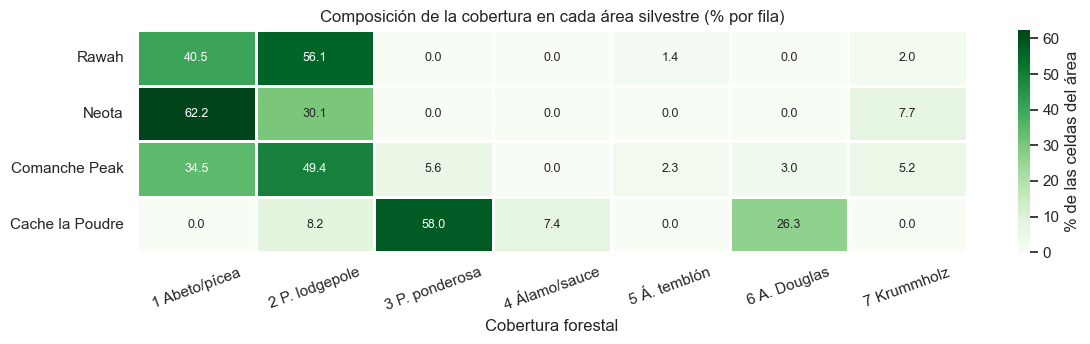

,Celdas,Proporción del total (%),Elevación mínima (m),Elevación mediana (m),Elevación máxima (m),Dist. mediana a carreteras (m)
Rawah,260796,44.9,2473,3002.0,3686,3155.0
Neota,29884,5.1,2945,3240.0,3647,914.0
Comanche Peak,253364,43.6,2270,2997.0,3858,1831.0
Cache la Poudre,36968,6.4,1859,2313.0,2654,696.0


In [2]:
area_all = wilderness_label(X)
composicion = pd.crosstab(area_all, y, normalize="index").loc[list(WILD_NAMES.values())]
composicion.columns = ETIQUETAS
resumen_area = pd.DataFrame({
    "Celdas": area_all.value_counts(),
    "Proporción del total (%)": 100 * area_all.value_counts(normalize=True),
    "Elevación mínima (m)": X.groupby(area_all)["Elevation"].min(),
    "Elevación mediana (m)": X.groupby(area_all)["Elevation"].median(),
    "Elevación máxima (m)": X.groupby(area_all)["Elevation"].max(),
    "Dist. mediana a carreteras (m)": X.groupby(area_all)["Horizontal_Distance_To_Roadways"].median(),
}).loc[list(WILD_NAMES.values())].round(1)

fig, ax = plt.subplots(figsize=(12, 3.6))
sns.heatmap(100 * composicion, annot=True, fmt=".1f", cmap="Greens", cbar_kws={"label": "% de las celdas del área"},
            linewidths=1, linecolor="white", ax=ax, annot_kws={"size": 9})
ax.set_xlabel("Cobertura forestal")
ax.set_ylabel("")
ax.set_title("Composición de la cobertura en cada área silvestre (% por fila)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()
resumen_area.astype({"Celdas": int})

La composición confirma que cada área ocupa un segmento distinto del gradiente. **Neota** es la más alta (mediana de 3.240 m) y está dominada por pícea y abeto (62 %), con la mayor proporción de *krummholz* (7,7 %). **Rawah** y **Comanche Peak** son las áreas grandes del piso subalpino y montano superior, dominadas por el pino contorta y el bosque de pícea y abeto, y entre ambas aportan el 88 % de las celdas. **Cache la Poudre** es un sistema distinto: con una elevación mediana de 2.313 m, no contiene pícea y abeto ni *krummholz*, está dominada por el pino ponderosa (58 %) y el abeto Douglas (26 %), y es la **única área donde existe la cobertura ribereña de álamo y sauce**. También es el área más próxima a la red vial (mediana de 696 m a una carretera, frente a 1.831 m en Comanche Peak y 3.155 m en Rawah), lo que refleja su mayor exposición antrópica. Neota, pese a su carácter remoto, registra una distancia mediana de 914 m, porque su superficie reducida queda próxima al corredor del paso Cameron.

Esta segregación geográfica tiene una consecuencia metodológica directa: el área silvestre actúa como un indicador regional del piso altitudinal y de la flora disponible, y un modelo puede apoyarse en ella como atajo para reconocer las clases confinadas a un área.

### 1.3 Las siete coberturas forestales

| Clase | Cobertura | Especies dominantes | Piso y nicho ecológico |
|---|---|---|---|
| 1 | **Pícea y abeto** (*Spruce/Fir*) | *Picea engelmannii*, *Abies lasiocarpa* | Bosque subalpino de clímax, fresco y húmedo, con acumulación de nieve prolongada; especies tolerantes a la sombra que se regeneran bajo dosel |
| 2 | **Pino contorta** (*Lodgepole Pine*) | *Pinus contorta* var. *latifolia* | Montano superior y subalpino; especie pionera con conos serótinos que se abren con el fuego y forma rodales coetáneos tras incendios de reemplazo {cite}`romme1981` |
| 3 | **Pino ponderosa** (*Ponderosa Pine*) | *Pinus ponderosa* var. *scopulorum* | Montano inferior, laderas secas y cálidas orientadas al sur; corteza gruesa adaptada a incendios superficiales frecuentes |
| 4 | **Álamo y sauce** (*Cottonwood/Willow*) | *Populus angustifolia*, *Salix* spp. | Bosque de galería ribereño en fondos de valle bajos; depende de un nivel freático somero y de la dinámica de inundación |
| 5 | **Álamo temblón** (*Aspen*) | *Populus tremuloides* | Montano y subalpino en sitios mésicos; especie clonal que rebrota de raíz tras perturbaciones y suele ser sucedida por coníferas {cite}`mitton1996` |
| 6 | **Abeto Douglas** (*Douglas-fir*) | *Pseudotsuga menziesii* var. *glauca* | Montano inferior y medio, preferentemente en laderas orientadas al norte, más frescas y húmedas que las del pino ponderosa |
| 7 | ***Krummholz*** | Formas achaparradas de *Picea engelmannii*, *Abies lasiocarpa* y *Pinus flexilis* | Ecotono del límite arbóreo; árboles deformados por el viento, la abrasión por hielo y la escasa estación de crecimiento {cite}`holtmeier2005` |

Las clases no son unidades florísticas excluyentes. Tres de ellas (pícea y abeto, pino contorta y álamo temblón) pueden ocupar el mismo sitio en distintos momentos de una secuencia sucesional, y el *krummholz* está formado por las mismas especies que el bosque subalpino, diferenciadas por su forma de crecimiento. Estos solapamientos ecológicos anticipan los pares de coberturas que ningún clasificador basado solo en topografía podrá separar por completo.

### 1.4 Factores físicos que gobiernan la distribución

**Zonificación altitudinal (gradiente térmico vertical).** La temperatura del aire desciende aproximadamente 6 a 6,5 °C por cada 1.000 m de ascenso, mientras la precipitación, sobre todo la nival, aumenta con la altitud. El resultado es una secuencia de pisos de vegetación en la que cada especie ocupa la franja compatible con sus límites de tolerancia a la sequía (límite inferior) y al frío y a la brevedad de la estación de crecimiento (límite superior) {cite}`peet1981`.

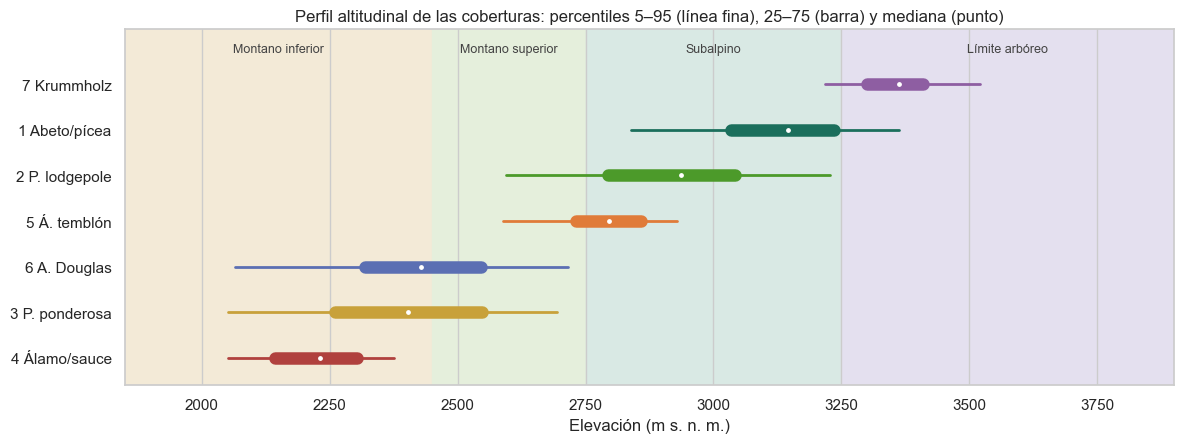

In [3]:
pisos = [
    (1850, 2450, "Montano inferior", "#f3ead7"),
    (2450, 2750, "Montano superior", "#e5efdc"),
    (2750, 3250, "Subalpino", "#d9e9e4"),
    (3250, 3900, "Límite arbóreo", "#e4e0ef"),
]
perc = X_train.groupby(y_train)["Elevation"].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
orden = perc[0.5].sort_values().index

fig, ax = plt.subplots(figsize=(12, 4.6))
for lo, hi, nombre, color in pisos:
    ax.axvspan(lo, hi, color=color, zorder=0)
    ax.text((lo + hi) / 2, len(orden) - 0.35, nombre, ha="center", va="bottom", fontsize=9, color="#444444")
for i, k in enumerate(orden):
    ax.plot([perc.loc[k, 0.05], perc.loc[k, 0.95]], [i, i], color=CLASS_PALETTE[k], lw=2, solid_capstyle="round")
    ax.plot([perc.loc[k, 0.25], perc.loc[k, 0.75]], [i, i], color=CLASS_PALETTE[k], lw=9, solid_capstyle="round")
    ax.plot(perc.loc[k, 0.5], i, "o", color="white", ms=5, mec=CLASS_PALETTE[k], mew=1.5)
ax.set_yticks(range(len(orden)))
ax.set_yticklabels([CLASS_SHORT[k] for k in orden])
ax.set_ylim(-0.6, len(orden) + 0.2)
ax.set_xlim(1850, 3900)
ax.set_xlabel("Elevación (m s. n. m.)")
ax.set_title("Perfil altitudinal de las coberturas: percentiles 5–95 (línea fina), 25–75 (barra) y mediana (punto)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

El perfil reproduce la zonificación clásica de la Cordillera Frontal {cite}`peet1981`. El álamo y el sauce ocupan los fondos de valle más bajos (mediana de 2.231 m); el pino ponderosa y el abeto Douglas comparten el piso montano inferior con rangos casi idénticos; el álamo temblón y el pino contorta ocupan el montano superior; la pícea y el abeto dominan el subalpino, y el *krummholz* marca el límite arbóreo (mediana de 3.363 m). Los rangos intercuartílicos de clases contiguas se solapan, lo que sitúa a cada transición altitudinal como una zona de incertidumbre.

**Insolación y sombra topográfica.** Los índices de sombreado (*hillshade*) estiman, en una escala de 0 a 255, la iluminación de cada celda a las 9:00, a las 12:00 y a las 15:00 en el solsticio de verano, combinando la posición del sol con la orientación y la pendiente del terreno. En el hemisferio norte las laderas orientadas al sur y al suroeste reciben más radiación directa, son más cálidas y pierden más agua por evapotranspiración; las orientadas al norte conservan la humedad y la nieve. El índice de las 9:00 es alto en laderas orientadas al este y el de las 15:00, en las orientadas al oeste, por lo que su combinación codifica la orientación, y el del mediodía, sobre todo la pendiente. Esta partición microclimática es la que separa, dentro del mismo piso, al pino ponderosa (laderas cálidas) del abeto Douglas (laderas frescas):

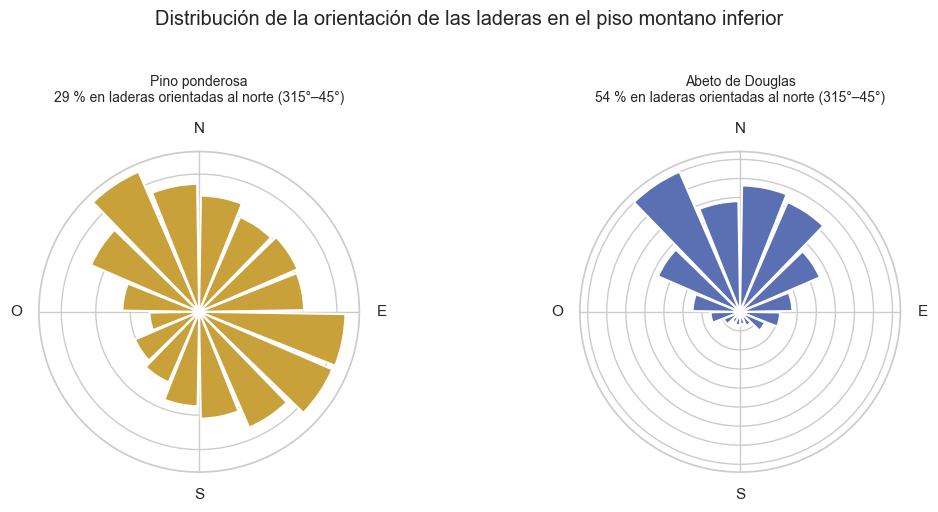

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), subplot_kw={"projection": "polar"})
bordes = np.deg2rad(np.arange(0, 361, 22.5))
for ax, k in zip(axes, [3, 6]):
    az = np.deg2rad(X_train.loc[y_train == k, "Aspect"] % 360)
    conteo, _ = np.histogram(az, bins=bordes)
    ax.bar(bordes[:-1] + np.diff(bordes) / 2, conteo / conteo.sum(), width=np.diff(bordes) * 0.92,
           color=CLASS_PALETTE[k], edgecolor="white", linewidth=1.5)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
    ax.set_xticklabels(["N", "E", "S", "O"])
    ax.set_yticklabels([])
    norte = ((X_train.loc[y_train == k, "Aspect"] >= 315) | (X_train.loc[y_train == k, "Aspect"] <= 45)).mean()
    ax.set_title(f"{CLASS_NAMES[k]}\n{100 * norte:.0f} % en laderas orientadas al norte (315°–45°)", fontsize=10, pad=14)
fig.suptitle("Distribución de la orientación de las laderas en el piso montano inferior", y=1.02)
plt.tight_layout()
plt.show()

El 54 % de las celdas de abeto Douglas está en laderas orientadas al norte, frente al 29 % del pino ponderosa, y apenas el 6 % del abeto Douglas aparece en laderas orientadas al sur. La orientación desplaza el límite entre ambas especies sin necesidad de cambios de altitud.

**Pendiente.** La pendiente controla la profundidad del suelo, la escorrentía y la acumulación de nieve. Las laderas abruptas del cañón del Poudre (pendiente mediana de 19° a 21° en las clases 3, 4 y 6) tienen suelos someros y pedregosos, mientras que las mesetas subalpinas (12° a 13° en las clases 1, 2 y 7) acumulan suelo y nieve. Además, la pendiente modula el efecto de la orientación: una ladera plana recibe la misma radiación sea cual sea su orientación.

**Proximidad a fuentes hidrológicas.** Las distancias horizontal y vertical al curso de agua superficial más cercano describen la posición de la celda en la cuenca. Son decisivas para la vegetación ribereña: la mediana de la distancia horizontal del álamo y el sauce es de 30 m, frente a 130–280 m del resto de las coberturas.

**Proximidad a vías y a puntos de ignición.** La distancia a carreteras actúa como indicador de accesibilidad y de presión antrópica, pero también de posición topográfica, porque las vías siguen los fondos de valle. La distancia a puntos históricos de ignición de incendios resume la exposición al régimen de fuego. Ambas son menores en las coberturas del piso montano inferior (medianas de 800–1.000 m) que en las subalpinas (1.800–2.700 m).

### 1.5 Formulación del problema

Sea $\mathbf{x} \in \mathbb{R}^{54}$ el vector de atributos cartográficos de una celda (10 variables continuas, 4 indicadoras de área silvestre y 40 indicadoras de tipo de suelo) y $y \in \{1, \dots, 7\}$ su cobertura dominante. El problema es estimar una función $f: \mathbb{R}^{54} \to \{1, \dots, 7\}$ que generalice a celdas no observadas de las mismas áreas, con desempeño evaluado tanto globalmente como por clase.

**Pregunta de investigación.** ¿En qué medida los atributos topográficos, hidrológicos y edáficos de un sitio determinan su cobertura forestal, y qué parte de la variabilidad de la cobertura queda fuera del alcance de un modelo lineal en el espacio de predictoras?

**Hipótesis de trabajo.**

1. **H1.** La elevación es el principal determinante de la cobertura y su efecto reproduce la zonificación altitudinal descrita.
2. **H2.** Un clasificador lineal multinomial supera ampliamente a cualquier regla trivial, pero su error se concentra en pares de coberturas con nichos topográficos solapados.
3. **H3.** Parte de la confusión es estructural: obedece a procesos (historia de incendios, sucesión, microclima local) que las variables cartográficas no registran.

## 2. Justificación metodológica del preprocesamiento y la validación

El diseño metodológico se adopta íntegramente de la fase exploratoria del proyecto {cite}`galvan2026fase1`: la misma partición estratificada 80/20 con semilla 42, la misma ingeniería de variables y la configuración del clasificador seleccionada por validación cruzada estratificada de 5 pliegues sobre una rejilla de 12 combinaciones (ingeniería de variables, $C = 1{,}0$ y sin ponderación de clases; F1 macro de validación de 0,566 ± 0,013). Esta sección examina la justificación técnica de cada decisión.

### 2.1 Variables continuas cartográficas frente a indicadoras binarias

In [5]:
prev_suelo = X_train[SOIL_COLS].mean()
tipologia = pd.DataFrame(
    [
        ("Continuas cartográficas", len(NUM_COLS), "m, °, índice 0–255",
         "Ingeniería determinista + StandardScaler"),
        ("Indicadoras de área silvestre", len(WILD_COLS), "0/1 (one-hot)", "Sin transformar (passthrough)"),
        ("Indicadoras de tipo de suelo", len(SOIL_COLS), "0/1 (one-hot)", "Sin transformar (passthrough)"),
    ],
    columns=["Grupo", "Variables", "Escala", "Tratamiento"],
).set_index("Grupo")
display(tipologia)

raros = prev_suelo[prev_suelo < 0.001].sort_values()
pd.DataFrame({
    "Celdas en entrenamiento": (raros * len(X_train)).round().astype(int),
    "Prevalencia (%)": (100 * raros).round(4),
}).rename_axis("Tipos de suelo con prevalencia < 0,1 %")

,Variables,Escala,Tratamiento
Grupo,,,
Continuas cartográficas,10,"m, °, índice 0–255",Ingeniería determinista + StandardScaler
Indicadoras de área silvestre,4,0/1 (one-hot),Sin transformar (passthrough)
Indicadoras de tipo de suelo,40,0/1 (one-hot),Sin transformar (passthrough)


,Celdas en entrenamiento,Prevalencia (%)
"Tipos de suelo con prevalencia < 0,1 %",,
Soil_Type_15,3,0.0006
Soil_Type_7,83,0.0179
Soil_Type_36,90,0.0194
Soil_Type_8,149,0.0321
Soil_Type_37,236,0.0508
Soil_Type_25,372,0.0800
Soil_Type_14,457,0.0983


Las 10 variables continuas y las 44 indicadoras tienen naturalezas distintas y reciben un tratamiento diferenciado dentro de un `ColumnTransformer`:

- **Variables continuas.** Se someten a transformaciones deterministas (seno y coseno de la orientación para respetar su carácter circular; $\log(1+x)$ de las tres distancias horizontales para reducir su asimetría positiva; distancia euclidiana al agua, $\sqrt{d_h^2 + d_v^2}$; y elevación relativa al curso de agua) y luego se estandarizan.
- **Indicadoras de área y suelo.** Las variables categóricas originales (área silvestre, 4 niveles, y unidad de suelo ELU del USFS, 40 niveles) ya están codificadas en formato *one-hot* y son consistentes: cada celda tiene exactamente un área y un suelo activos. Se conservan como 0/1 sin escalar por tres razones. Primera, su coeficiente mantiene una lectura directa como desplazamiento del *log-odds* de la clase cuando la celda pertenece a esa categoría. Segunda, estandarizar una indicadora rara la convertiría en una variable de magnitud desproporcionada: el suelo 15, con 3 celdas en entrenamiento, alcanzaría un valor tipificado cercano a 390 en esas celdas, lo que distorsionaría la penalización. Tercera, al no haber categoría de referencia, la suma de las indicadoras de cada bloque es constante e igual a 1, colineal con el intercepto. La penalización L2 de la regresión logística resuelve esa indeterminación: entre todas las soluciones equivalentes elige la de norma mínima, de modo que los coeficientes se interpretan como contrastes respecto al promedio del bloque.
- **Categorías raras.** Siete tipos de suelo tienen prevalencia inferior al 0,1 %. No se agrupan, porque los suelos raros se asocian con coberturas distintas entre sí y su agregación mezclaría señales; la penalización L2 encoge sus coeficientes hacia cero cuando la evidencia es escasa.

### 2.2 Escalamiento: magnitudes y asimetría topográfica

In [6]:
X_eng_train = engineer_features(X_train)
magnitudes = X_train[NUM_COLS].agg(["mean", "std", "min", "max", "skew"]).T
magnitudes["Asimetría tras ingeniería"] = [
    X_eng_train[c].skew() if c in X_eng_train else np.nan for c in NUM_COLS
]
magnitudes.columns = ["Media", "Desv. estándar", "Mínimo", "Máximo", "Asimetría original", "Asimetría tras ingeniería"]
magnitudes.index = [DISPLAY_NAMES[c] for c in magnitudes.index]
magnitudes.round(2)

,Media,Desv. estándar,Mínimo,Máximo,Asimetría original,Asimetría tras ingeniería
Elevación (m),2959.51,280.03,1860.0,3858.0,-0.82,-0.82
Orientación (° azimut),155.83,111.98,0.0,360.0,0.40,NaN
Pendiente (°),14.10,7.49,0.0,66.0,0.79,0.79
Dist. horizontal a agua (m),269.35,212.39,0.0,1397.0,1.14,-2.14
Dist. vertical a agua (m),46.42,58.23,-166.0,601.0,1.79,1.79
Dist. a carreteras (m),2351.82,1559.33,0.0,7117.0,0.71,-1.00
Sombreado 9 a. m. (0-255),212.13,26.76,0.0,254.0,-1.18,-1.18
Sombreado mediodía (0-255),223.32,19.77,0.0,254.0,-1.06,-1.06
Sombreado 3 p. m. (0-255),142.55,38.27,0.0,254.0,-0.28,-0.28
Dist. a puntos de incendio (m),1979.97,1323.56,0.0,7172.0,1.29,-0.80


Las magnitudes difieren en más de dos órdenes: la desviación estándar de la elevación es de 280 m, la de la distancia a carreteras de 1.559 m y la de la pendiente de 7,5°. En una regresión logística con penalización L2, el término $\lambda \lVert \boldsymbol{\beta} \rVert^2$ trata por igual a todos los coeficientes; sin escalamiento, la penalización recaería de forma desigual sobre variables medidas en unidades distintas, y el problema de optimización quedaría mal condicionado, con una convergencia más lenta del algoritmo L-BFGS. La estandarización hace que cada coeficiente represente el efecto de una desviación estándar de la variable y que todos sean comparables.

La elección entre `StandardScaler` (media y desviación estándar) y `RobustScaler` (mediana y rango intercuartílico) depende de la influencia de los valores extremos. Las variables con mayor asimetría (las distancias horizontales, con coeficientes de 0,7 a 1,3) se transforman previamente con $\log(1+x)$, y la fase exploratoria mostró que los valores atípicos topográficos son legítimos: corresponden a las cotas más bajas del cañón del Poudre o a laderas muy abruptas, donde se concentran las clases minoritarias. La comparación empírica de ambos escaladores con la misma validación cruzada estratificada confirma que la diferencia es despreciable:

In [7]:
def preprocesador_robusto():
    escala = ColumnTransformer([("num", RobustScaler(), ENG_NUM_COLS), ("bin", "passthrough", BIN_COLS)])
    return Pipeline([("features", FunctionTransformer(engineer_features)), ("scale", escala)])

X_sub, y_sub = stratified_sample(X_train, y_train, 30000)
filas = []
for nombre, prep in [("StandardScaler", build_preprocessor(engineered=True)), ("RobustScaler", preprocesador_robusto())]:
    pipe = Pipeline([("prep", prep), ("clf", LogisticRegression(C=BEST_PARAMS["C"], max_iter=3000, random_state=RANDOM_STATE))])
    r = cross_validate(pipe, X_sub, y_sub, cv=cv5, scoring=["accuracy", "f1_macro"], n_jobs=-1)
    filas.append({"Escalador": nombre, "Accuracy (media)": r["test_accuracy"].mean(),
                  "F1 macro (media)": r["test_f1_macro"].mean(), "F1 macro (desv. est.)": r["test_f1_macro"].std()})
pd.DataFrame(filas).set_index("Escalador").round(4)

,Accuracy (media),F1 macro (media),F1 macro (desv. est.)
Escalador,,,
StandardScaler,0.7229,0.5658,0.0128
RobustScaler,0.7229,0.5644,0.0136


Ambos escaladores producen el mismo *accuracy* y una diferencia de F1 macro de una milésima, muy inferior a la desviación entre pliegues. Se mantiene `StandardScaler` porque, una vez aplicada la transformación logarítmica, no hay colas que distorsionen la media, y porque expresa los coeficientes en unidades de desviación estándar, la convención habitual para comparar su magnitud.

### 2.3 Validación cruzada estratificada frente al desbalance

La clase más frecuente (pino contorta, 48,8 %) es 103 veces más abundante que la menos frecuente (álamo y sauce, 0,47 %). Con una partición aleatoria simple, el número de celdas de las clases raras en cada pliegue fluctúa al azar, y con él la estimación de sus métricas. La comparación de los pliegues generados por `KFold` y `StratifiedKFold` sobre la misma submuestra de 30.000 celdas ilustra el efecto:

In [8]:
filas = []
for nombre, cv in [("KFold aleatorio", KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)), ("StratifiedKFold", cv5)]:
    for i, (_, te) in enumerate(cv.split(X_sub, y_sub), start=1):
        conteo = y_sub.iloc[te].value_counts()
        filas.append({"Esquema": nombre, "Pliegue": i, **{CLASS_SHORT[k]: conteo.get(k, 0) for k in [4, 5, 6, 7]}})
pliegues = pd.DataFrame(filas)
variacion = pliegues.groupby("Esquema")[[CLASS_SHORT[k] for k in [4, 5, 6, 7]]].agg(lambda s: f"{s.min()}–{s.max()} (CV {100 * s.std() / s.mean():.1f} %)")
variacion.columns.name = "Celdas por pliegue: rango (coef. de variación)"
variacion

Celdas por pliegue: rango (coef. de variación),4 Álamo/sauce,5 Á. temblón,6 A. Douglas,7 Krummholz
Esquema,,,,
KFold aleatorio,25–34 (CV 13.8 %),90–109 (CV 7.7 %),162–200 (CV 7.7 %),194–230 (CV 6.3 %)
StratifiedKFold,28–29 (CV 1.9 %),98–98 (CV 0.0 %),179–180 (CV 0.3 %),211–212 (CV 0.2 %)


Con `KFold` el álamo y el sauce varían entre 25 y 34 celdas por pliegue (coeficiente de variación del 13,8 %), y el álamo temblón entre 90 y 109; con `StratifiedKFold` la diferencia entre pliegues es como máximo de una celda. La estratificación garantiza que cada pliegue reproduce la distribución de clases de la población, reduce la varianza de la estimación de las métricas por clase y evita pliegues en los que una clase rara quede subrepresentada. El mismo principio se aplica a la partición entre entrenamiento y prueba, estratificada por la variable objetivo.

La elección de la métrica complementa la estratificación. El *accuracy* está dominado por las dos clases mayoritarias (87 % de las celdas), por lo que la selección de hiperparámetros se basó en el **F1 macro**, que promedia el F1 de las siete clases con igual peso y penaliza a un modelo que ignore las minoritarias.

### 2.4 Prevención de fugas de información

El diseño del *pipeline* sigue cinco salvaguardas frente a la fuga de información {cite}`kaufman2012`:

1. **Reserva temprana del conjunto de prueba.** La partición 80/20 se realiza antes de cualquier análisis que conduzca a decisiones de modelado. El conjunto de prueba se usa una única vez, en la evaluación final de la sección 4.
2. **Ingeniería de variables sin parámetros aprendidos.** Seno, coseno, logaritmo, distancia euclidiana y diferencia de elevaciones son funciones fijas aplicadas fila a fila; no pueden transferir información entre observaciones.
3. **Escalamiento dentro del `Pipeline`.** Las medias y desviaciones del `StandardScaler` se estiman solo con la porción de entrenamiento de cada pliegue y, en el ajuste final, solo con el conjunto de entrenamiento. El conjunto de prueba se transforma con esos parámetros.
4. **Hiperparámetros seleccionados sin el conjunto de prueba.** La configuración reutilizada se eligió por validación cruzada exclusivamente sobre el entrenamiento.
5. **Auditoría de predictoras.** No existen identificadores, variables derivadas de la cobertura ni variables posteriores a ella. La elevación y el área de Cache la Poudre tienen un poder discriminante univariado muy alto para algunas clases, pero por razones ecológicas y geográficas legítimas.

Persiste una fuente de optimismo que el diseño no puede eliminar: la autocorrelación espacial. Las celdas vecinas comparten atributos y cobertura, y el conjunto no incluye coordenadas que permitan construir bloques espaciales. Las métricas deben interpretarse, por tanto, como desempeño dentro de las áreas muestreadas; la validación dejando fuera un área completa redujo el *accuracy* a 0,57 en la fase exploratoria {cite}`galvan2026fase1`.

La estructura completa del *pipeline* es la siguiente:

In [9]:
build_logreg(**BEST_PARAMS, max_iter=3000)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('features',
                                  FunctionTransformer(func=<function engineer_features at 0x0000023EE38281F0>)),
                                 ('scale',
                                  ColumnTransformer(transformers=[('num',
                                                                   StandardScaler(),
                                                                   ['Elevation',
                                                                    'Slope',
                                                                    'Horizontal_Distance_To_Hydrology',
                                                                    'Vertical_Distance_To_Hydrology',
                                                                    'Horizontal_Distance_To_Roadways',
                                                                    'Hillshade_9am',
                                                                    'Hillshade_Noon',
                                                                    'H...
                                                                    'Soil_Type_8',
                                                                    'Soil_Type_9',
                                                                    'Soil_Type_10',
                                                                    'Soil_Type_11',
                                                                    'Soil_Type_12',
                                                                    'Soil_Type_13',
                                                                    'Soil_Type_14',
                                                                    'Soil_Type_15',
                                                                    'Soil_Type_16',
                                                                    'Soil_Type_17',
                                                                    'Soil_Type_18',
                                                                    'Soil_Type_19',
                                                                    'Soil_Type_20',
                                                                    'Soil_Type_21',
                                                                    'Soil_Type_22',
                                                                    'Soil_Type_23',
                                                                    'Soil_Type_24',
                                                                    'Soil_Type_25',
                                                                    'Soil_Type_26', ...])]))])),
                ('clf', LogisticRegression(max_iter=3000, random_state=42))])

## 3. Análisis exploratorio con interpretación biofísica

Todos los análisis de esta sección se calculan sobre el conjunto de entrenamiento (464.809 celdas).

### 3.1 Desbalance de clases

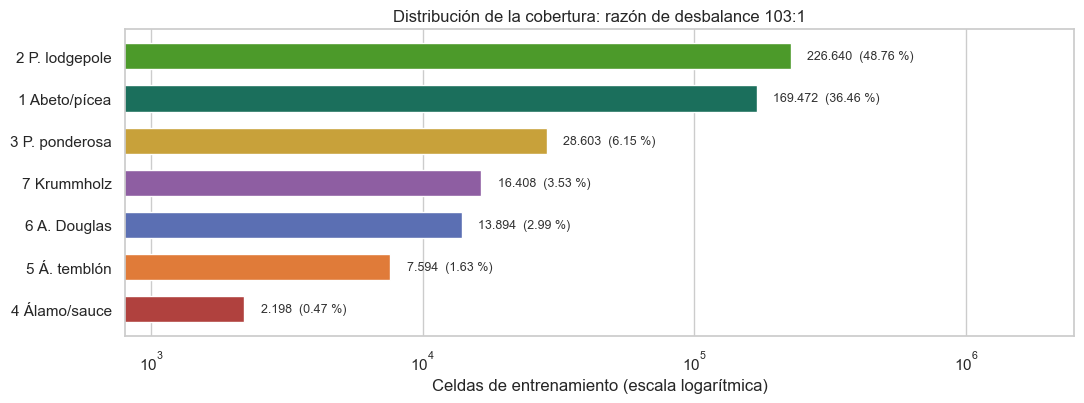

In [10]:
conteo = y_train.value_counts().sort_index()
prop = 100 * conteo / conteo.sum()
orden = conteo.sort_values().index

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.barh([CLASS_SHORT[k] for k in orden], conteo[orden], color=[CLASS_PALETTE[k] for k in orden], height=0.62)
for i, k in enumerate(orden):
    ax.text(conteo[k] * 1.15, i, f"{conteo[k]:,}  ({prop[k]:.2f} %)".replace(",", "."), va="center", fontsize=9, color="#333333")
ax.set_xscale("log")
ax.set_xlim(800, 2.5e6)
ax.set_xlabel("Celdas de entrenamiento (escala logarítmica)")
ax.set_title(f"Distribución de la cobertura: razón de desbalance {conteo.max() / conteo.min():.0f}:1")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Implicaciones ecológicas.** El desbalance no es un artefacto del muestreo sino un reflejo de la estructura del paisaje. El pino contorta y el bosque de pícea y abeto forman la matriz continua del piso subalpino, que domina la superficie de Rawah, Comanche Peak y Neota. El álamo y el sauce, en cambio, forman bosques de galería lineales confinados a los fondos de valle de una sola área, y el álamo temblón aparece en manchas clonales discontinuas. Las coberturas raras son precisamente las de mayor valor de conservación: los corredores ribereños concentran biodiversidad y regulan la calidad del agua, y los rodales de álamo temblón son hábitats clave y cortafuegos naturales.

**Implicaciones algorítmicas.** La regresión logística minimiza la entropía cruzada promedio sobre todas las celdas, de modo que el 87 % de la función de pérdida corresponde a las clases 1 y 2. El modelo tiende a desplazar las fronteras de decisión hacia las clases raras: una celda ambigua entre pino contorta y álamo temblón se asigna a la primera porque su probabilidad *a priori* es 30 veces mayor. Esto justifica tres decisiones ya descritas: la estratificación de la partición y de los pliegues, el uso del F1 macro como métrica de selección y el reporte de métricas por clase. La ponderación de clases (`class_weight="balanced"`) se evaluó en la fase exploratoria y eleva el *recall* de las clases raras a costa de su precisión y del *accuracy* global {cite}`galvan2026fase1`; el modelo base se mantiene sin ponderar, de acuerdo con el criterio de F1 macro.

### 3.2 Correlación entre variables físicas y multicolinealidad

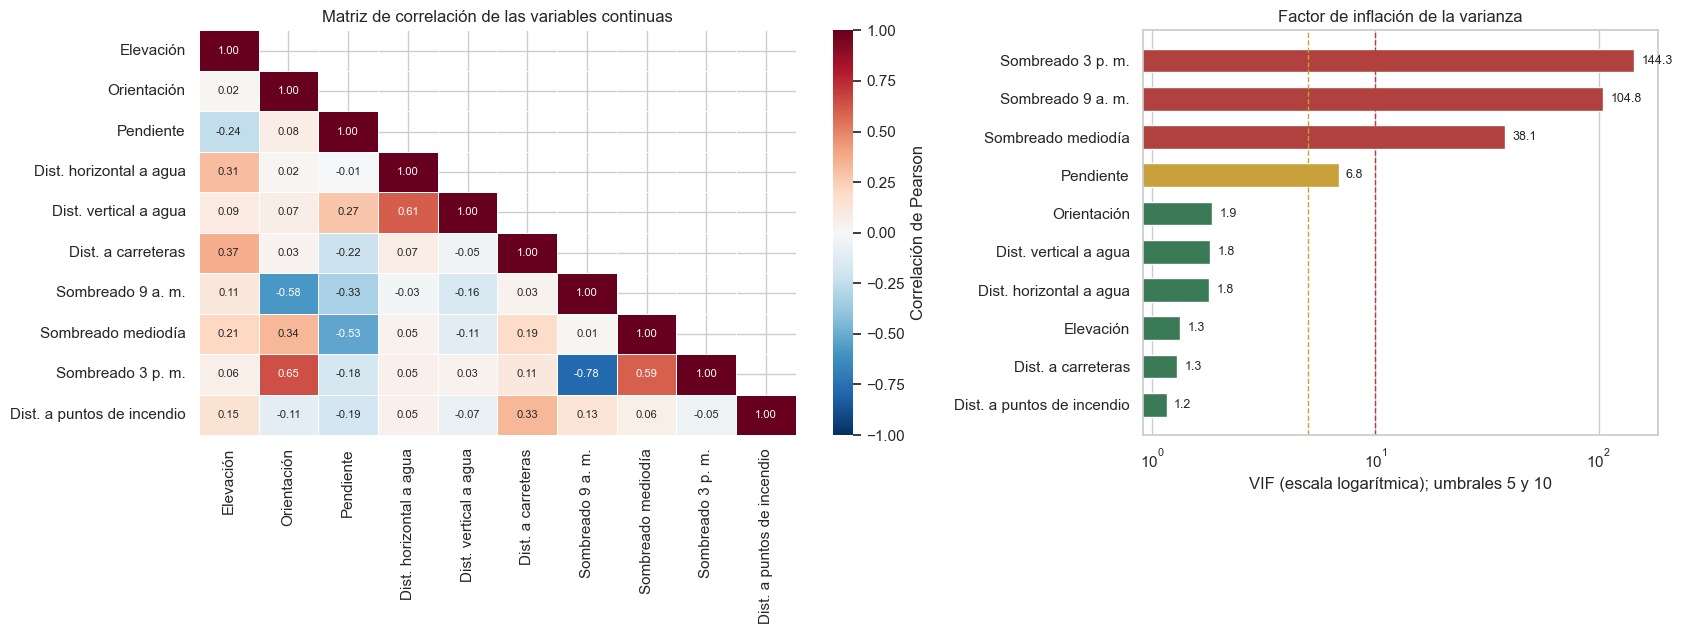

In [11]:
corr = X_train[NUM_COLS].corr()
R_inv = np.linalg.inv(corr.to_numpy())
vif = pd.Series(np.diag(R_inv), index=NUM_COLS)
nombres_cortos = {c: DISPLAY_NAMES[c].split(" (")[0] for c in NUM_COLS}

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1.45, 1]})
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr.rename(index=nombres_cortos, columns=nombres_cortos), mask=mascara, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="white", ax=axes[0],
            annot_kws={"size": 8}, cbar_kws={"label": "Correlación de Pearson"})
axes[0].set_title("Matriz de correlación de las variables continuas")
v = vif.rename(index=nombres_cortos).sort_values()
colores = ["#b0413e" if x > 10 else ("#c8a13a" if x > 5 else "#3b7a57") for x in v]
axes[1].barh(v.index, v.values, color=colores, height=0.62)
axes[1].axvline(5, color="#c8a13a", ls="--", lw=1)
axes[1].axvline(10, color="#b0413e", ls="--", lw=1)
axes[1].set_xscale("log")
for i, x in enumerate(v.values):
    axes[1].text(x * 1.08, i, f"{x:.1f}", va="center", fontsize=9)
axes[1].set_xlabel("VIF (escala logarítmica); umbrales 5 y 10")
axes[1].set_title("Factor de inflación de la varianza")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

El factor de inflación de la varianza se obtiene de la diagonal de la inversa de la matriz de correlación, $\mathrm{VIF}_j = [\mathbf{R}^{-1}]_{jj}$, y cuantifica cuánto se infla la varianza del coeficiente de la variable $j$ por su dependencia lineal de las demás.

- **Bloque de iluminación redundante.** Los tres índices de sombreado tienen VIF de 38, 105 y 144. No es una coincidencia estadística sino una consecuencia física: los tres se calculan a partir de la orientación y la pendiente con la geometría solar del solsticio. El índice de las 9:00 y el de las 15:00 están correlacionados negativamente (−0,78), porque una ladera iluminada por la mañana queda en sombra por la tarde, y ambos dependen de la orientación (−0,58 y 0,65). El índice del mediodía depende sobre todo de la pendiente (−0,53).
- **Hidrología.** Las distancias horizontal y vertical al agua se correlacionan moderadamente (0,61): cuanto más lejos del cauce, más alto respecto a él. La distancia euclidiana construida en la ingeniería de variables combina ambas.
- **Elevación.** Tiene un VIF de 1,3: aporta información prácticamente independiente del resto. Su correlación con la distancia a carreteras (0,37) refleja que la red vial ocupa los valles bajos.

La multicolinealidad no compromete la capacidad predictiva, ya que la penalización L2 estabiliza la estimación, pero sí condiciona la **interpretación**: los coeficientes de los índices de sombreado y de las dos variables altitudinales no pueden leerse de forma aislada (sección 5.4).

### 3.3 Distribución de las predictoras por cobertura

La capacidad discriminante de cada variable continua se resume con la razón de correlación $\eta^2 = SS_\text{entre} / SS_\text{total}$, la proporción de su varianza explicada por la pertenencia a una cobertura.

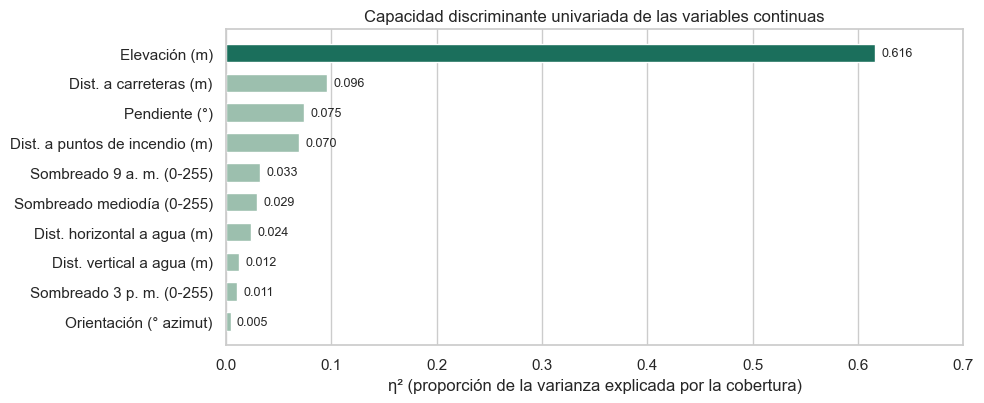

In [12]:
def eta_cuadrado(x, grupos):
    media = x.mean()
    entre = sum(len(g) * (g.mean() - media) ** 2 for _, g in x.groupby(grupos))
    return entre / ((x - media) ** 2).sum()

eta2 = pd.Series({DISPLAY_NAMES[c]: eta_cuadrado(X_train[c], y_train) for c in NUM_COLS}).sort_values()
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(eta2.index, eta2.values, color=["#1b6f5c" if v == eta2.max() else "#9cbfae" for v in eta2.values], height=0.62)
for i, v in enumerate(eta2.values):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 0.7)
ax.set_xlabel("η² (proporción de la varianza explicada por la cobertura)")
ax.set_title("Capacidad discriminante univariada de las variables continuas")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

La **elevación explica el 62 % de su varianza a través de la cobertura**, un valor seis veces superior al de la segunda variable (distancia a carreteras, 0,10). Las variables de iluminación, orientación e hidrología tienen un $\eta^2$ inferior a 0,035: su efecto no es global sino que se manifiesta en contrastes concretos entre pares de coberturas, como el de la orientación entre el pino ponderosa y el abeto Douglas.

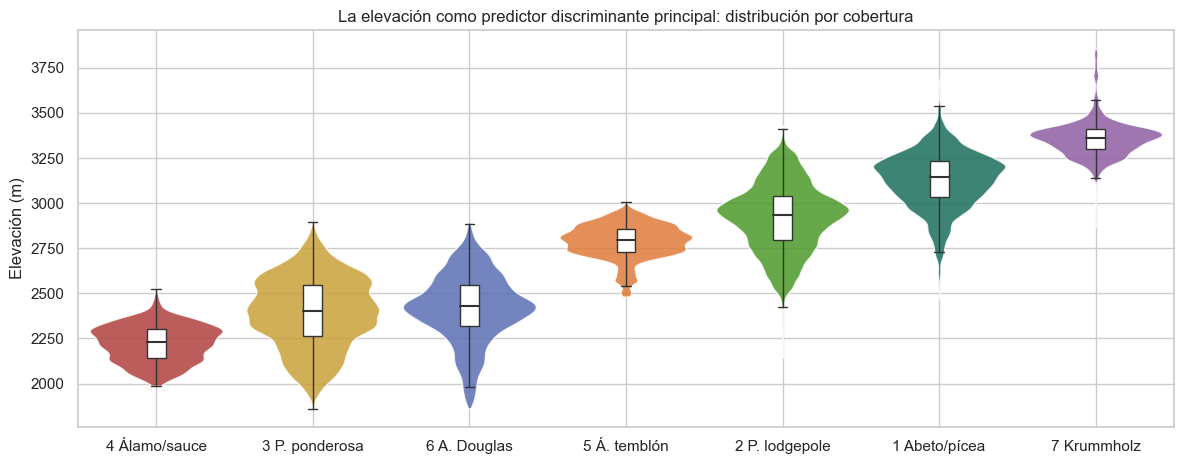

In [13]:
orden_elev = X_train.groupby(y_train)["Elevation"].median().sort_values().index
fig, ax = plt.subplots(figsize=(12, 4.8))
datos = [X_train.loc[y_train == k, "Elevation"] for k in orden_elev]
partes = ax.violinplot(datos, showextrema=False, widths=0.85)
for cuerpo, k in zip(partes["bodies"], orden_elev):
    cuerpo.set_facecolor(CLASS_PALETTE[k])
    cuerpo.set_edgecolor("white")
    cuerpo.set_alpha(0.85)
ax.boxplot(datos, widths=0.12, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="white", color="#333333"), medianprops=dict(color="#333333", lw=1.5),
           whiskerprops=dict(color="#333333"), capprops=dict(color="#333333"))
ax.set_xticks(range(1, 8))
ax.set_xticklabels([CLASS_SHORT[k] for k in orden_elev])
ax.set_ylabel("Elevación (m)")
ax.set_title("La elevación como predictor discriminante principal: distribución por cobertura")
plt.tight_layout()
plt.show()

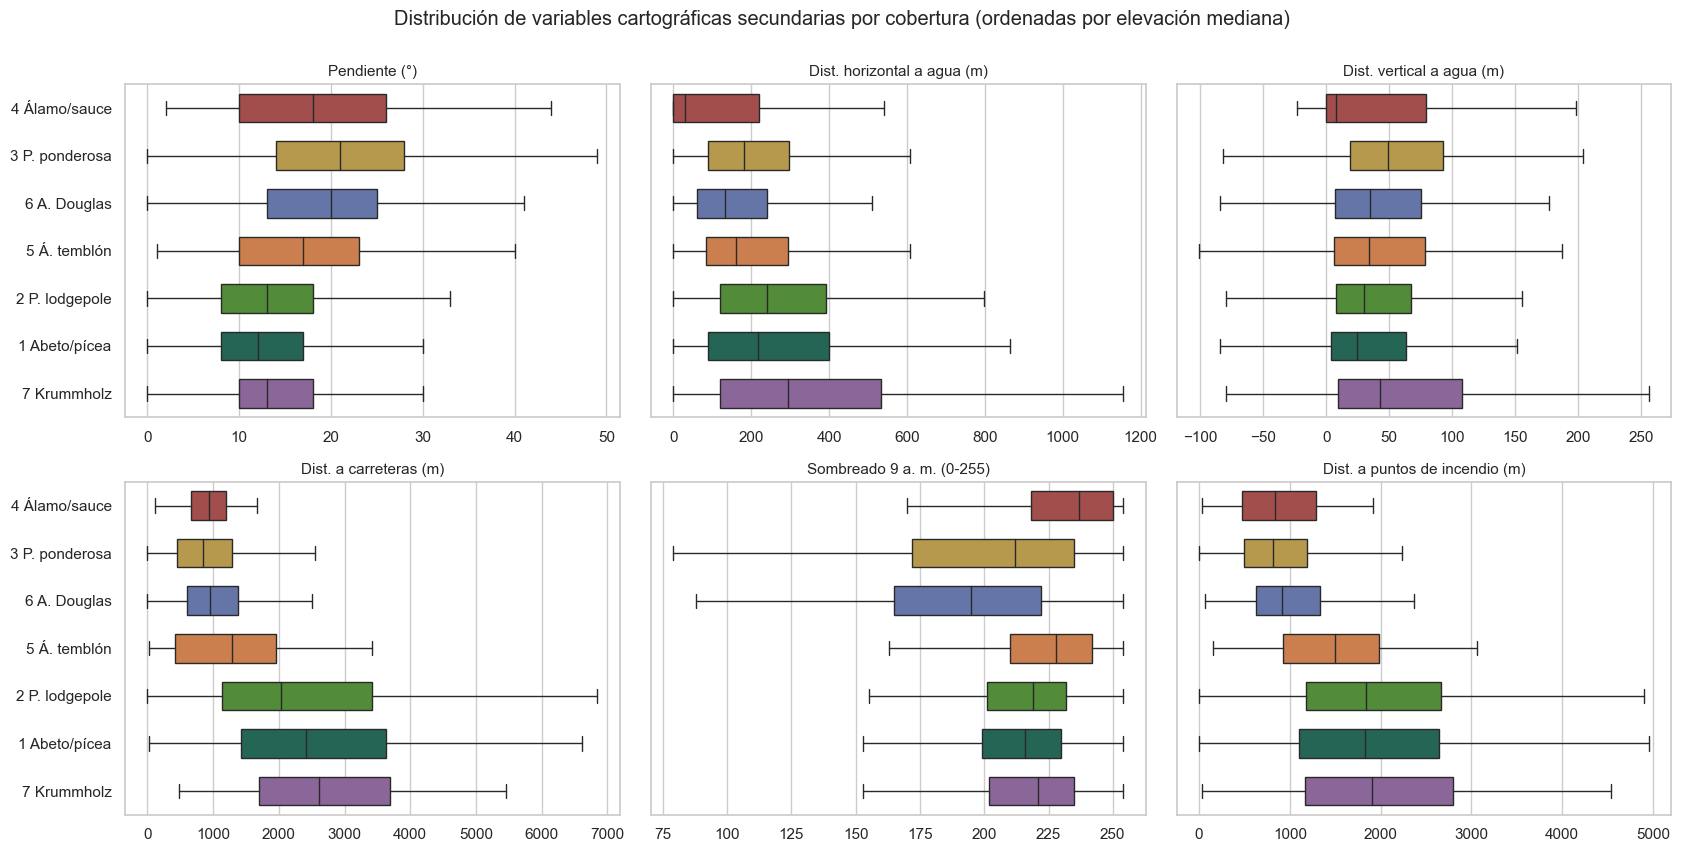

In [14]:
variables = ["Slope", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",
             "Horizontal_Distance_To_Roadways", "Hillshade_9am", "Horizontal_Distance_To_Fire_Points"]
muestra = X_train.assign(Cobertura=y_train.map(CLASS_SHORT)).sample(60000, random_state=RANDOM_STATE)
orden_nombres = [CLASS_SHORT[k] for k in orden_elev]
paleta = {CLASS_SHORT[k]: CLASS_PALETTE[k] for k in CLASES}
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5), sharey=True)
for ax, col in zip(axes.ravel(), variables):
    sns.boxplot(data=muestra, x=col, y="Cobertura", order=orden_nombres, palette=paleta, showfliers=False,
                width=0.6, linewidth=1, ax=ax)
    ax.set_title(DISPLAY_NAMES[col], fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distribución de variables cartográficas secundarias por cobertura (ordenadas por elevación mediana)", y=1.0)
plt.tight_layout()
plt.show()

Las distribuciones secundarias refuerzan la lectura ecológica:

- **Pendiente.** Las coberturas del cañón (pino ponderosa, abeto Douglas, álamo y sauce) ocupan laderas más inclinadas que las subalpinas, coherentes con la morfología del cañón del Poudre frente a las mesetas glaciares de Rawah y Neota.
- **Hidrología.** El álamo y el sauce son la única cobertura cuya distribución se concentra junto al agua, tanto en distancia horizontal (mediana de 30 m) como vertical (6 m). Ninguna otra clase muestra dependencia comparable.
- **Iluminación matinal.** El abeto Douglas tiene el índice de las 9:00 más bajo (mediana de 196 frente a 213–235 en el resto), señal de su preferencia por laderas en sombra.
- **Vías e incendios.** Las distancias a carreteras y a puntos de ignición separan con claridad el bloque montano inferior del subalpino, pero apenas discriminan dentro de cada bloque: funcionan como indicadores regionales de la posición en el paisaje.

En conjunto, la exploración anticipa la arquitectura del problema: un eje dominante (la elevación) que ordena las clases en tres bloques (montano inferior, montano superior y subalpino) y ejes secundarios que solo separan pares concretos dentro de cada bloque.

## 4. Evaluación del modelo base: regresión logística multinomial

### 4.1 Especificación

La regresión logística multinomial modela la probabilidad de cada cobertura mediante la función *softmax* de siete funciones lineales del vector de predictoras transformado $\tilde{\mathbf{x}}$ (57 variables tras la ingeniería):

$$
P(y = k \mid \mathbf{x}) = \frac{\exp(\beta_{k0} + \boldsymbol{\beta}_k^\top \tilde{\mathbf{x}})}{\sum_{j=1}^{7} \exp(\beta_{j0} + \boldsymbol{\beta}_j^\top \tilde{\mathbf{x}})}, \qquad k = 1, \dots, 7,
$$

y estima los coeficientes minimizando la entropía cruzada con penalización L2 de intensidad $1/C$, con $C = 1{,}0$. La frontera entre dos clases cualesquiera es un hiperplano en el espacio de $\tilde{\mathbf{x}}$, lo que define tanto la interpretabilidad del modelo como su límite de expresividad. El modelo se ajusta con las 464.809 celdas de entrenamiento y se compara con tres clasificadores triviales (`DummyClassifier`) que ignoran las predictoras: la clase más frecuente, el azar uniforme y el azar estratificado según las proporciones de clase.

In [15]:
inicio = time.time()
modelo = build_logreg(**BEST_PARAMS, max_iter=3000)
modelo.fit(X_train, y_train)
print(f"Ajuste con {len(X_train):,} celdas: {time.time() - inicio:.0f} s; "
      f"iteraciones de L-BFGS: {modelo.named_steps['clf'].n_iter_[0]}".replace(",", "."))

dummies = {
    "Dummy (más frecuente)": DummyClassifier(strategy="most_frequent"),
    "Dummy (uniforme)": DummyClassifier(strategy="uniform", random_state=RANDOM_STATE),
    "Dummy (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}
for d in dummies.values():
    d.fit(X_train, y_train)

pred_test = modelo.predict(X_test)
pred_train = modelo.predict(X_train)

Ajuste con 464.809 celdas: 207 s; iteraciones de L-BFGS: 1178


### 4.2 Comparación formal con la línea base

In [16]:
METRICAS = ["Accuracy", "Precisión macro", "Recall macro", "F1 macro", "Exactitud balanceada", "F1 ponderado"]

def metricas(y_true, pred):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precisión macro": precision_score(y_true, pred, average="macro", zero_division=0),
        "Recall macro": recall_score(y_true, pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "Exactitud balanceada": balanced_accuracy_score(y_true, pred),
        "F1 ponderado": f1_score(y_true, pred, average="weighted", zero_division=0),
    }

res_test = {nombre: metricas(y_test, d.predict(X_test)) for nombre, d in dummies.items()}
res_test["Regresión logística"] = metricas(y_test, pred_test)
tabla_test = pd.DataFrame(res_test).T[METRICAS]

# Intervalos de confianza del 95 % por bootstrap percentil (200 remuestreos del conjunto de prueba)
rng = np.random.default_rng(RANDOM_STATE)
yt, pt = y_test.to_numpy(), pred_test
boot = []
for _ in range(200):
    i = rng.integers(0, len(yt), len(yt))
    boot.append(metricas(yt[i], pt[i]))
boot = pd.DataFrame(boot)
ic = pd.DataFrame({"IC 95 % inferior": boot.quantile(0.025), "IC 95 % superior": boot.quantile(0.975)}).loc[METRICAS]
tabla_test.round(3)

,Accuracy,Precisión macro,Recall macro,F1 macro,Exactitud balanceada,F1 ponderado
Dummy (más frecuente),0.488,0.070,0.143,0.094,0.143,0.320
Dummy (uniforme),0.143,0.142,0.145,0.094,0.145,0.191
Dummy (estratificado),0.374,0.141,0.141,0.141,0.141,0.374
Regresión logística,0.724,0.653,0.531,0.557,0.531,0.716


,Regresión logística,IC 95 %,Mejor dummy en la métrica,Ganancia absoluta,Ganancia relativa (%)
Accuracy,0.724,0.722–0.727,0.488,0.237,48.510
Precisión macro,0.653,0.640–0.667,0.142,0.510,358.576
Recall macro,0.531,0.525–0.538,0.145,0.386,265.748
F1 macro,0.557,0.551–0.564,0.141,0.416,293.986
Exactitud balanceada,0.531,0.525–0.538,0.145,0.386,265.748
F1 ponderado,0.716,0.713–0.719,0.374,0.342,91.359


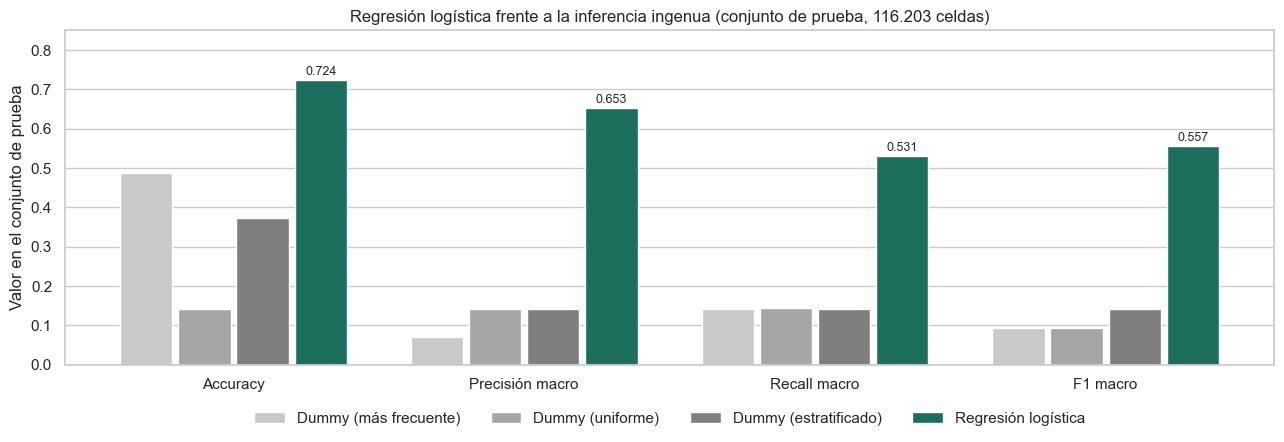

In [17]:
mejor_dummy = tabla_test.loc[[n for n in tabla_test.index if n.startswith("Dummy")]].max()
ganancia = pd.DataFrame({
    "Regresión logística": tabla_test.loc["Regresión logística"],
    "IC 95 %": [f"{ic.loc[m, 'IC 95 % inferior']:.3f}–{ic.loc[m, 'IC 95 % superior']:.3f}" for m in METRICAS],
    "Mejor dummy en la métrica": mejor_dummy,
    "Ganancia absoluta": tabla_test.loc["Regresión logística"] - mejor_dummy,
    "Ganancia relativa (%)": 100 * (tabla_test.loc["Regresión logística"] / mejor_dummy - 1),
})
display(ganancia.round(3))

fig, ax = plt.subplots(figsize=(13, 4.6))
modelos = ["Dummy (más frecuente)", "Dummy (uniforme)", "Dummy (estratificado)", "Regresión logística"]
colores = ["#c9c9c9", "#a6a6a6", "#7f7f7f", "#1b6f5c"]
ancho = 0.2
pos = np.arange(4)
for j, (m, c) in enumerate(zip(modelos, colores)):
    valores = tabla_test.loc[m, METRICAS[:4]].to_numpy()
    barras = ax.bar(pos + (j - 1.5) * ancho, valores, width=ancho - 0.02, color=c, label=m)
    if m == "Regresión logística":
        for b, v in zip(barras, valores):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(pos)
ax.set_xticklabels(METRICAS[:4])
ax.set_ylim(0, 0.85)
ax.set_ylabel("Valor en el conjunto de prueba")
ax.set_title("Regresión logística frente a la inferencia ingenua (conjunto de prueba, 116.203 celdas)")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

La regresión logística supera a las tres estrategias triviales en todas las métricas, con intervalos de confianza estrechos (amplitud cercana a medio punto porcentual en el *accuracy* y a un punto en el F1 macro) gracias al tamaño del conjunto de prueba:

- **Frente al clasificador mayoritario**, que predice siempre pino contorta y acierta el 48,8 % de las celdas, el modelo gana 23,7 puntos de *accuracy*. Esa cifra subestima la ganancia real, porque el *accuracy* del mayoritario es un artefacto del desbalance: su F1 macro es 0,094 y su exactitud balanceada, exactamente $1/7$.
- **En las métricas que ponderan las clases por igual**, la ganancia es mucho mayor: el F1 macro pasa de 0,141 (mejor *dummy*, estratificado) a 0,557, un aumento relativo cercano al 290 %; la precisión macro, de 0,142 a 0,653, y el *recall* macro, de 0,145 a 0,531.
- **Precisión frente a *recall*.** La precisión macro (0,653) supera al *recall* macro (0,531): cuando el modelo asigna una clase minoritaria suele acertar, pero omite muchas de sus celdas. Es el sesgo hacia las clases frecuentes descrito en la sección 3.1.

La ganancia neta demuestra que las variables cartográficas contienen información sustancial sobre la cobertura y que el modelo multivariado la extrae: la hipótesis H2 se confirma en su primera parte.

### 4.3 Diagnóstico de ajuste: entrenamiento frente a prueba

In [18]:
res_train = metricas(y_train, pred_train)
brecha = pd.DataFrame({"Entrenamiento": res_train, "Prueba": res_test["Regresión logística"]}).loc[METRICAS]
brecha["Brecha (entrenamiento − prueba)"] = brecha["Entrenamiento"] - brecha["Prueba"]
brecha.round(4)

,Entrenamiento,Prueba,Brecha (entrenamiento − prueba)
Accuracy,0.7258,0.7241,0.0016
Precisión macro,0.6588,0.6528,0.0060
Recall macro,0.5335,0.5314,0.0021
F1 macro,0.5585,0.5573,0.0012
Exactitud balanceada,0.5335,0.5314,0.0021
F1 ponderado,0.7174,0.7158,0.0015


Las métricas de entrenamiento y prueba difieren en menos de dos milésimas en todos los casos, y en las métricas macro la brecha es del orden de la incertidumbre del *bootstrap*. Con 57 predictoras y más de 8.000 celdas por parámetro de cada clase, la varianza del estimador es mínima: **el modelo no sobreajusta**. La curva de aprendizaje permite distinguir entre las dos explicaciones posibles de un desempeño moderado, un modelo con datos insuficientes o un modelo demasiado simple.

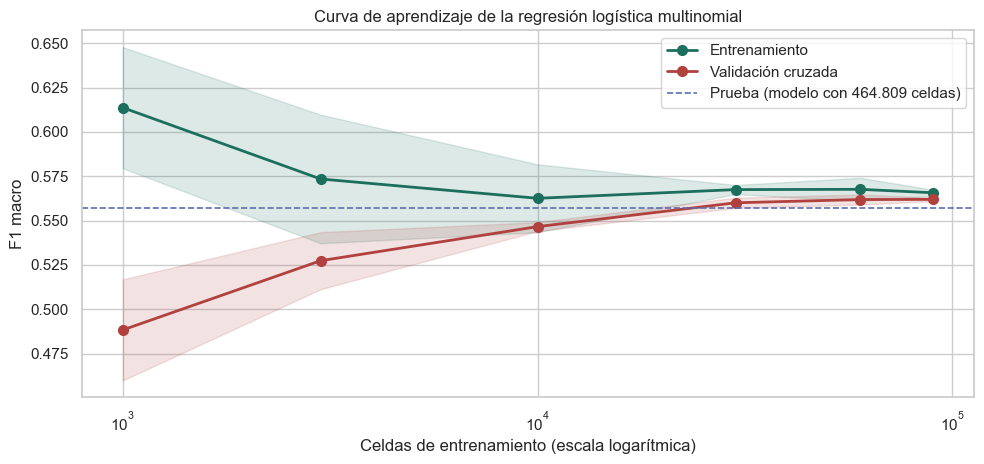

Celdas,1000,3000,10000,30000,60000,90000
F1 entrenamiento,0.6137,0.5735,0.5626,0.5675,0.5676,0.5657
F1 validación,0.4883,0.5274,0.5466,0.5600,0.5619,0.5620
Brecha,0.1254,0.0461,0.0160,0.0074,0.0058,0.0037


In [19]:
X_lc, y_lc = stratified_sample(X_train, y_train, 120000)
tamanos, sc_train, sc_val = learning_curve(
    build_logreg(**BEST_PARAMS, max_iter=3000), X_lc, y_lc,
    train_sizes=[1000, 3000, 10000, 30000, 60000, 90000],
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE),
    scoring="f1_macro", n_jobs=-1, shuffle=True, random_state=RANDOM_STATE,
)
fig, ax = plt.subplots(figsize=(10, 4.8))
for sc, nombre, color in [(sc_train, "Entrenamiento", "#1b6f5c"), (sc_val, "Validación cruzada", "#b0413e")]:
    ax.plot(tamanos, sc.mean(axis=1), "o-", color=color, lw=2, ms=7, label=nombre)
    ax.fill_between(tamanos, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1), color=color, alpha=0.15)
ax.axhline(res_test["Regresión logística"]["F1 macro"], color="#5b6fb3", ls="--", lw=1.2,
           label="Prueba (modelo con 464.809 celdas)")
ax.set_xscale("log")
ax.set_xlabel("Celdas de entrenamiento (escala logarítmica)")
ax.set_ylabel("F1 macro")
ax.set_title("Curva de aprendizaje de la regresión logística multinomial")
ax.legend()
plt.tight_layout()
plt.show()
curva = pd.DataFrame({"Celdas": tamanos, "F1 entrenamiento": sc_train.mean(axis=1), "F1 validación": sc_val.mean(axis=1)})
curva["Brecha"] = curva["F1 entrenamiento"] - curva["F1 validación"]
curva.set_index("Celdas").round(4).T

La curva de aprendizaje separa con claridad los dos regímenes:

- **Con muestras pequeñas** (1.000 celdas) hay sobreajuste: el F1 macro de entrenamiento supera al de validación en más de diez puntos, porque las clases raras tienen apenas unas decenas de ejemplos.
- **A partir de unas 30.000 celdas** ambas curvas son planas y prácticamente coincidentes, y convergen al valor obtenido en prueba con el conjunto completo.

La convergencia de las curvas en un nivel moderado (F1 macro ≈ 0,56) es la firma del **subajuste por sesgo**: agregar datos no mejoraría el modelo, porque el límite está en su forma funcional lineal. La fase exploratoria lo corroboró con un modelo no lineal de referencia (*gradient boosting*) que, con los mismos datos, alcanzó 0,81 de *accuracy* y 0,74 de F1 macro {cite}`galvan2026fase1`. La sección 5 identifica dónde se origina ese sesgo.

## 5. Matriz de confusión y diagnóstico detallado de errores

### 5.1 Matrices de confusión absoluta y normalizada

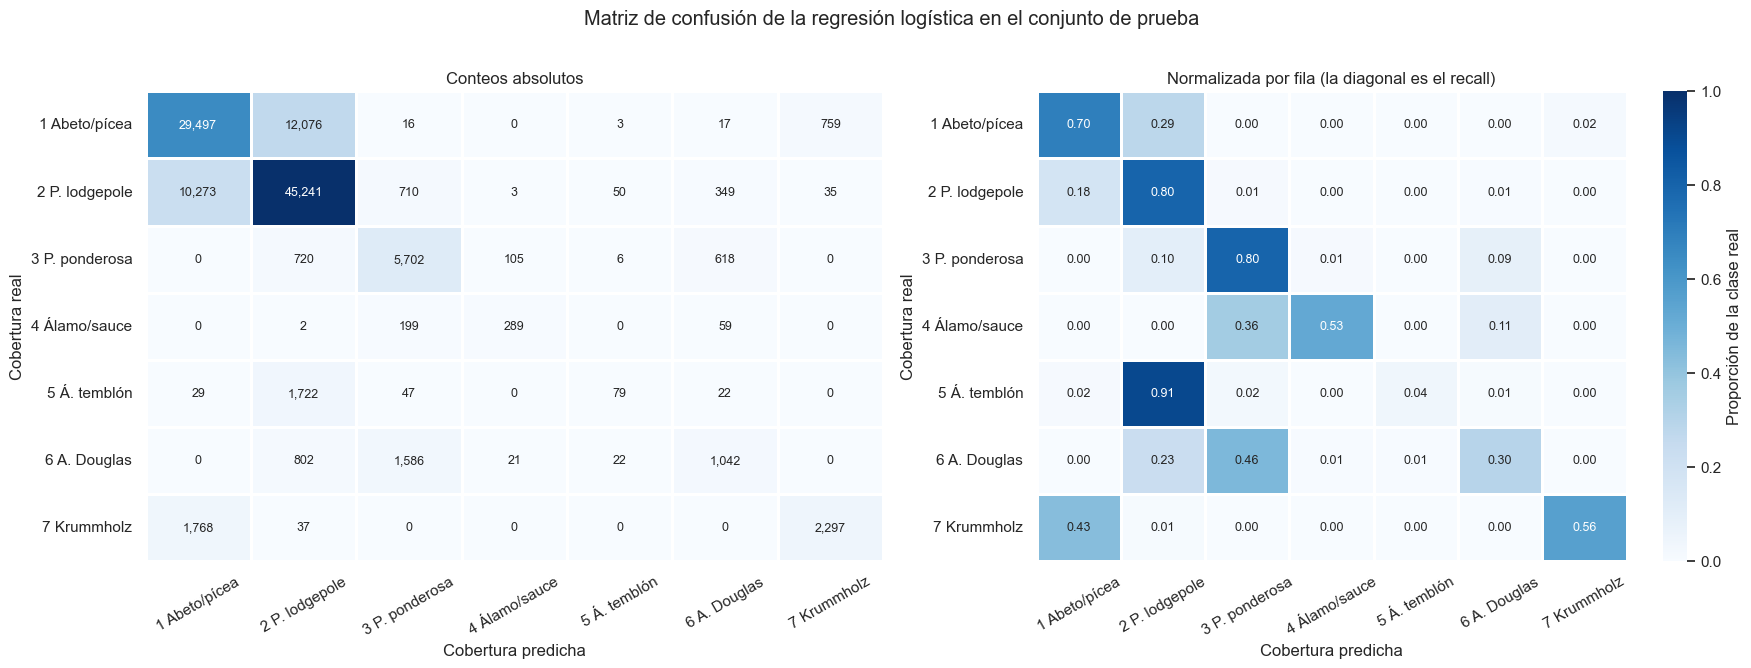

,Precisión,Recall,F1,Soporte
1 Abeto/pícea,0.710,0.696,0.703,42368
2 P. lodgepole,0.747,0.798,0.772,56661
3 P. ponderosa,0.690,0.797,0.740,7151
4 Álamo/sauce,0.691,0.526,0.598,549
5 Á. temblón,0.494,0.042,0.077,1899
6 A. Douglas,0.495,0.300,0.373,3473
7 Krummholz,0.743,0.560,0.639,4102


In [20]:
cm = confusion_matrix(y_test, pred_test, labels=CLASES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 6.6))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[0], xticklabels=ETIQUETAS, yticklabels=ETIQUETAS,
            cbar=False, linewidths=1, linecolor="white", annot_kws={"size": 9})
axes[0].set_title("Conteos absolutos")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], xticklabels=ETIQUETAS, yticklabels=ETIQUETAS,
            vmin=0, vmax=1, linewidths=1, linecolor="white", annot_kws={"size": 9},
            cbar_kws={"label": "Proporción de la clase real"})
axes[1].set_title("Normalizada por fila (la diagonal es el recall)")
for ax in axes:
    ax.set_xlabel("Cobertura predicha")
    ax.set_ylabel("Cobertura real")
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Matriz de confusión de la regresión logística en el conjunto de prueba", y=1.01)
plt.tight_layout()
plt.show()

reporte = pd.DataFrame(classification_report(y_test, pred_test, output_dict=True, zero_division=0)).T
reporte = reporte.loc[[str(k) for k in CLASES]]
reporte.index = ETIQUETAS
reporte.columns = ["Precisión", "Recall", "F1", "Soporte"]
reporte["Soporte"] = reporte["Soporte"].astype(int)
reporte.round(3)

La diagonal normalizada muestra tres niveles de desempeño. Las dos clases mayoritarias y el pino ponderosa tienen un *recall* cercano a 0,70–0,80; el *krummholz* y el álamo y el sauce, en torno a 0,53–0,56; y el abeto Douglas (0,30) y, sobre todo, el álamo temblón (0,04) son prácticamente invisibles para el modelo. Los errores no se dispersan por toda la matriz: se concentran en unas pocas celdas fuera de la diagonal, siempre entre coberturas contiguas en el gradiente.

### 5.2 Los errores siguen el solapamiento altitudinal

Para cada par de coberturas se calcula el **coeficiente de solapamiento** de sus distribuciones de elevación en entrenamiento, $\mathrm{OVL} = \sum_b \min(p_{a,b}, p_{c,b})$, donde $p_{a,b}$ es la proporción de celdas de la clase $a$ en la franja de 20 m $b$. El índice vale 0 si las clases no comparten ninguna franja y 1 si sus distribuciones altitudinales son idénticas.

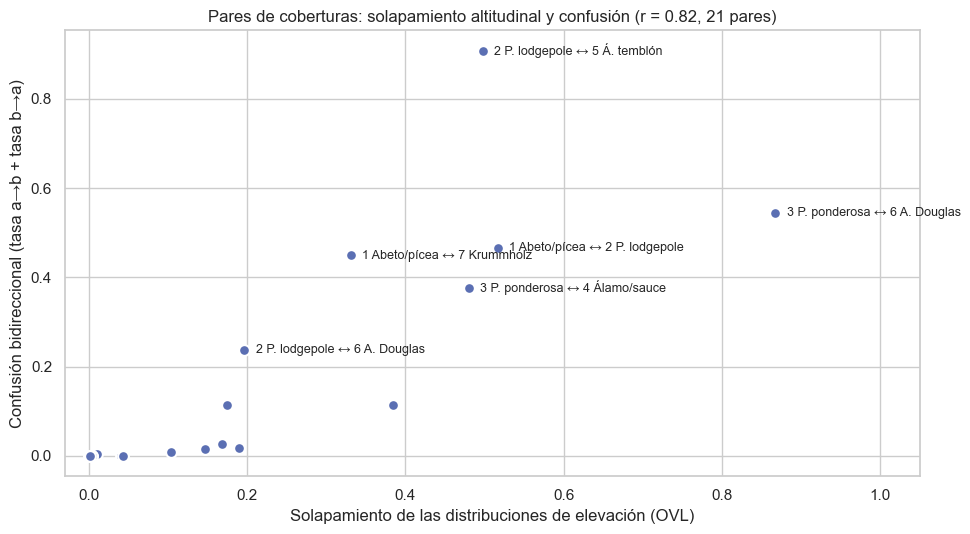

,Solapamiento altitudinal,Tasa a→b,Tasa b→a,Celdas confundidas
Par,,,,
1 Abeto/pícea ↔ 2 P. lodgepole,0.517,0.285,0.181,22349
1 Abeto/pícea ↔ 7 Krummholz,0.331,0.018,0.431,2527
3 P. ponderosa ↔ 6 A. Douglas,0.868,0.086,0.457,2204
2 P. lodgepole ↔ 5 Á. temblón,0.498,0.001,0.907,1772
2 P. lodgepole ↔ 3 P. ponderosa,0.175,0.013,0.101,1430
2 P. lodgepole ↔ 6 A. Douglas,0.197,0.006,0.231,1151
3 P. ponderosa ↔ 4 Álamo/sauce,0.480,0.015,0.362,304


In [21]:
bordes = np.arange(1850, 3900, 20)
hist = {k: np.histogram(X_train.loc[y_train == k, "Elevation"], bins=bordes)[0] / (y_train == k).sum() for k in CLASES}
pares = []
for a in CLASES:
    for b in CLASES:
        if a < b:
            pares.append({
                "Par": f"{CLASS_SHORT[a]} ↔ {CLASS_SHORT[b]}",
                "a": a, "b": b,
                "Solapamiento altitudinal": np.minimum(hist[a], hist[b]).sum(),
                "Tasa a→b": cm_norm[a - 1, b - 1],
                "Tasa b→a": cm_norm[b - 1, a - 1],
                "Celdas confundidas": cm[a - 1, b - 1] + cm[b - 1, a - 1],
            })
pares = pd.DataFrame(pares)
pares["Confusión bidireccional"] = pares["Tasa a→b"] + pares["Tasa b→a"]
r_pearson = np.corrcoef(pares["Solapamiento altitudinal"], pares["Confusión bidireccional"])[0, 1]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(pares["Solapamiento altitudinal"], pares["Confusión bidireccional"], s=60, color="#5b6fb3",
           edgecolor="white", linewidth=1.5, zorder=3)
for _, f in pares.nlargest(6, "Confusión bidireccional").iterrows():
    ax.annotate(f["Par"], (f["Solapamiento altitudinal"], f["Confusión bidireccional"]), xytext=(8, 0),
                textcoords="offset points", fontsize=9, va="center")
ax.set_xlabel("Solapamiento de las distribuciones de elevación (OVL)")
ax.set_ylabel("Confusión bidireccional (tasa a→b + tasa b→a)")
ax.set_title(f"Pares de coberturas: solapamiento altitudinal y confusión (r = {r_pearson:.2f}, 21 pares)")
ax.set_xlim(-0.03, 1.05)
plt.tight_layout()
plt.show()

tabla_pares = pares.sort_values("Celdas confundidas", ascending=False).head(7).set_index("Par")
tabla_pares[["Solapamiento altitudinal", "Tasa a→b", "Tasa b→a", "Celdas confundidas"]].round(3)

La correlación entre el solapamiento altitudinal de un par y su confusión es de 0,82: **cuanto más comparten dos coberturas su franja de elevación, más las confunde el modelo**. Los 14 pares con solapamiento inferior a 0,2 apenas registran confusiones. Los errores relevantes se concentran en cuatro transiciones ecológicas, cada una con un mecanismo distinto que explica por qué un clasificador lineal no las resuelve.

### 5.3 Análisis de solapamiento ecológico por transición

#### Pícea y abeto ↔ pino contorta: la transición sucesional

Es el error dominante en términos absolutos: más de 22.000 celdas de prueba, con el 28,5 % de la pícea y el abeto asignado al pino contorta y el 18,1 % del pino contorta asignado a la pícea y el abeto.

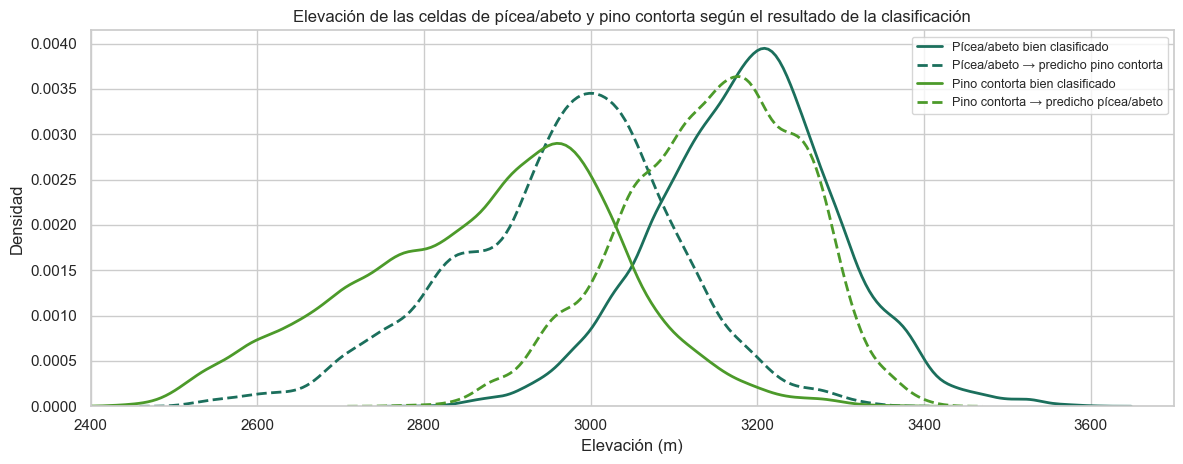

,Elevación mediana (m)
Pícea/abeto bien clasificado,3191.0
Pícea/abeto → predicho pino contorta,2981.0
Pino contorta bien clasificado,2899.0
Pino contorta → predicho pícea/abeto,3154.0


In [22]:
elev_test = X_test["Elevation"]
fig, ax = plt.subplots(figsize=(12, 4.8))
casos = [
    ((y_test == 1) & (pred_test == 1), "Pícea/abeto bien clasificado", CLASS_PALETTE[1], "-"),
    ((y_test == 1) & (pred_test == 2), "Pícea/abeto → predicho pino contorta", CLASS_PALETTE[1], "--"),
    ((y_test == 2) & (pred_test == 2), "Pino contorta bien clasificado", CLASS_PALETTE[2], "-"),
    ((y_test == 2) & (pred_test == 1), "Pino contorta → predicho pícea/abeto", CLASS_PALETTE[2], "--"),
]
medianas = {}
for mascara, nombre, color, estilo in casos:
    sns.kdeplot(elev_test[mascara], ax=ax, color=color, ls=estilo, lw=2, label=nombre)
    medianas[nombre] = elev_test[mascara].median()
ax.set_xlabel("Elevación (m)")
ax.set_ylabel("Densidad")
ax.set_xlim(2400, 3700)
ax.set_title("Elevación de las celdas de pícea/abeto y pino contorta según el resultado de la clasificación")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
pd.Series(medianas, name="Elevación mediana (m)").to_frame()

La figura revela el mecanismo: el modelo traza, en la práctica, un **umbral altitudinal** cercano a 3.050 m. Las celdas de pícea y abeto mal clasificadas tienen una elevación mediana de 2.981 m, unos 210 m por debajo de las bien clasificadas (3.191 m), y las de pino contorta mal clasificadas se sitúan a 3.154 m, por encima de las bien clasificadas (2.899 m). Cada clase se pierde en la porción de su nicho que invade el de la otra.

La causa ecológica es la **sucesión postincendio**. En el piso subalpino de la Cordillera Frontal, el pino contorta es una especie pionera que coloniza los sitios tras incendios de reemplazo gracias a sus conos serótinos; sin nuevas perturbaciones, la pícea de Engelmann y el abeto subalpino, tolerantes a la sombra, se establecen bajo su dosel y lo reemplazan en el transcurso de dos a cuatro siglos {cite}`romme1981,veblen2005`. En la franja de 2.800 a 3.300 m, por tanto, **la misma combinación de elevación, orientación, pendiente y suelo puede sostener cualquiera de las dos coberturas**: la que ocupa el sitio depende del tiempo transcurrido desde el último incendio, una variable ausente del conjunto de datos. Ningún clasificador, lineal o no, puede resolver por completo esta confusión con predictoras topográficas; parte del error es irreducible y responde a la hipótesis H3.

#### *Krummholz* ↔ pícea y abeto: el ecotono del límite arbóreo

El 43 % del *krummholz* se asigna a la pícea y el abeto, mientras que el error inverso es mínimo (1,8 %). Las celdas de *krummholz* mal clasificadas tienen una elevación mediana de 3.315 m, frente a 3.388 m de las bien clasificadas. El *krummholz* no es una comunidad florística distinta, sino la **forma de crecimiento** que adoptan la pícea de Engelmann y el abeto subalpino cuando el viento invernal, la abrasión por cristales de hielo y la desecación limitan el crecimiento vertical por encima de la capa de nieve protectora {cite}`holtmeier2005`. La posición del límite arbóreo depende de la exposición al viento dominante del oeste, de la acumulación de nieve y de la microtopografía, factores que se expresan a escalas inferiores a la celda de 30 m. El modelo dispone solo de la elevación y del suelo para separar ambas formas; como el *krummholz* es 10 veces menos frecuente que el bosque subalpino, la probabilidad *a priori* inclina la decisión hacia este último en toda la franja de transición.

#### Abeto Douglas ↔ pino ponderosa: la partición por orientación

Es el par con mayor solapamiento altitudinal (OVL = 0,87): las dos especies comparten prácticamente la misma franja de elevación en el piso montano inferior. El 46 % del abeto Douglas se asigna al pino ponderosa y solo el 9 % del pino ponderosa al abeto Douglas. Como mostró la sección 1.4, lo que separa a ambas especies es la orientación: el abeto Douglas ocupa laderas frescas orientadas al norte y el pino ponderosa, laderas cálidas orientadas al sur {cite}`peet1981`.

Esta señal existe, pero el modelo lineal la aprovecha de forma limitada por dos razones. Primera, el efecto de la orientación sobre el balance hídrico es **multiplicativo con la pendiente**: una ladera de 30° orientada al norte es mucho más fresca que una de 30° orientada al sur, pero en terreno llano la orientación es irrelevante. Esta interacción $\text{pendiente} \times \cos(\text{orientación})$ no puede expresarse como suma de efectos lineales. Segunda, la señal de orientación está repartida entre la orientación misma y los tres índices de sombreado, un bloque con VIF de hasta 144, cuyos coeficientes se compensan entre sí. El resultado es que, ante una celda ambigua, prevalece la clase más frecuente del piso: el pino ponderosa es dos veces más abundante que el abeto Douglas.

#### Álamo y sauce ↔ pino ponderosa y abeto Douglas: un gradiente de humedad no monótono

El 36 % del álamo y el sauce se clasifica como pino ponderosa y el 11 %, como abeto Douglas. La cobertura ribereña comparte con ambas especies la elevación, el área (Cache la Poudre) y buena parte de los suelos; su rasgo distintivo es la proximidad a un nivel freático somero.

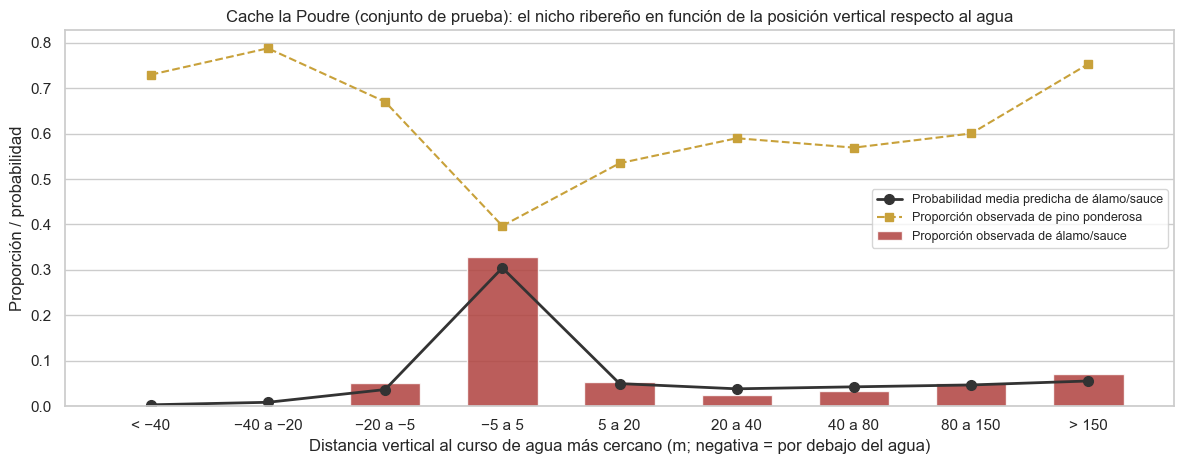

Celdas reales de álamo/sauce en las que su probabilidad es la mayor: 52.6%
Probabilidad media asignada al pino ponderosa en esas celdas: 0.371


franja,< −40,−40 a −20,−20 a −5,−5 a 5,5 a 20,20 a 40,40 a 80,80 a 150,> 150
Observada: álamo/sauce,0.000,0.000,0.052,0.328,0.053,0.024,0.033,0.051,0.070
Observada: pino ponderosa,0.730,0.788,0.670,0.397,0.535,0.590,0.569,0.600,0.754
Probabilidad predicha: álamo/sauce,0.003,0.009,0.037,0.304,0.050,0.038,0.043,0.047,0.055
Celdas,37.000,33.000,97.000,824.000,989.000,1190.000,1806.000,1659.000,702.000


In [23]:
mascara_cp = wilderness_label(X_test) == "Cache la Poudre"
X_cp, y_cp = X_test[mascara_cp], y_test[mascara_cp]
proba_cp = modelo.predict_proba(X_cp)
cortes_v = [-200, -40, -20, -5, 5, 20, 40, 80, 150, 700]
etiquetas_v = ["< −40", "−40 a −20", "−20 a −5", "−5 a 5", "5 a 20", "20 a 40", "40 a 80", "80 a 150", "> 150"]
perfil = pd.DataFrame({
    "franja": pd.cut(X_cp["Vertical_Distance_To_Hydrology"], cortes_v, labels=etiquetas_v),
    "Observada: álamo/sauce": (y_cp == 4).astype(float).to_numpy(),
    "Observada: pino ponderosa": (y_cp == 3).astype(float).to_numpy(),
    "Probabilidad predicha: álamo/sauce": proba_cp[:, 3],
})
resumen_perfil = perfil.groupby("franja").mean()
resumen_perfil["Celdas"] = perfil.groupby("franja").size()

fig, ax = plt.subplots(figsize=(12, 4.8))
xpos = np.arange(len(etiquetas_v))
ax.bar(xpos, resumen_perfil["Observada: álamo/sauce"], width=0.6, color=CLASS_PALETTE[4], alpha=0.85,
       label="Proporción observada de álamo/sauce")
ax.plot(xpos, resumen_perfil["Probabilidad predicha: álamo/sauce"], "o-", color="#333333", lw=2, ms=7,
        label="Probabilidad media predicha de álamo/sauce")
ax.plot(xpos, resumen_perfil["Observada: pino ponderosa"], "s--", color=CLASS_PALETTE[3], lw=1.5, ms=6,
        label="Proporción observada de pino ponderosa")
ax.set_xticks(xpos)
ax.set_xticklabels(etiquetas_v)
ax.set_xlabel("Distancia vertical al curso de agua más cercano (m; negativa = por debajo del agua)")
ax.set_ylabel("Proporción / probabilidad")
ax.set_title("Cache la Poudre (conjunto de prueba): el nicho ribereño en función de la posición vertical respecto al agua")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

prob_4 = modelo.predict_proba(X_test[y_test == 4])
print(f"Celdas reales de álamo/sauce en las que su probabilidad es la mayor: {(prob_4.argmax(axis=1) == 3).mean():.1%}")
print(f"Probabilidad media asignada al pino ponderosa en esas celdas: {prob_4[:, 2].mean():.3f}")
resumen_perfil.round(3).T

La relación entre la posición vertical respecto al agua y la cobertura ribereña es **no monótona**: la proporción de álamo y sauce alcanza un pico agudo (cercano al 33 %) en las celdas situadas a menos de 5 m de desnivel del cauce y cae a valores de entre el 0 % y el 7 % tanto por encima como por debajo. Un término lineal en la distancia vertical solo puede representar un efecto creciente o decreciente, nunca un máximo en torno a cero. En el modelo, el pico se recupera parcialmente gracias a la ingeniería de variables (el logaritmo de la distancia horizontal distingue con nitidez las celdas a distancia cero, y la distancia euclidiana combina ambos ejes), y por eso la probabilidad media predicha sigue el perfil observado.

El error persiste por otra razón: **el corredor ribereño es compartido**. Incluso en la franja más próxima al agua, el pino ponderosa ocupa una proporción incluso mayor que la del álamo y el sauce (≈ 40 % frente a ≈ 33 %), porque la capa hidrológica registra la distancia al cauce cartografiado, pero no la anchura de la llanura de inundación, la profundidad del nivel freático ni el régimen de crecidas, que son los factores que realmente determinan dónde puede establecerse el bosque de galería. La probabilidad del álamo y el sauce rara vez domina en una celda individual, y la decisión se inclina hacia la cobertura más frecuente del valle.

#### Álamo temblón ↔ pino contorta: una cobertura definida por la perturbación

El caso más extremo es el álamo temblón: el 90,7 % de sus celdas se asigna al pino contorta y su *recall* es de 0,04. Su nicho altitudinal (mediana de 2.796 m) está completamente contenido en el del pino contorta (OVL = 0,50), y las diferencias en las demás variables son modestas: celdas algo más cercanas a carreteras (mediana de 1.290 m frente a 2.040 m) y a puntos de ignición, y asociadas a ciertos suelos (los tipos 30, 13 y 29 reúnen la mitad de sus celdas). La razón es ecológica: el álamo temblón se reproduce sobre todo de forma clonal, rebrotando de un sistema radical que puede persistir durante siglos, y su presencia actual responde a la historia de incendios, a la herbivoría y a la persistencia de clones antiguos más que a las condiciones topográficas del sitio {cite}`mitton1996`. Con una probabilidad *a priori* 30 veces menor que la del pino contorta y sin variables de perturbación, el modelo nunca alcanza la evidencia necesaria para asignarlo.

### 5.4 Interpretación biofísica de los coeficientes

Como las variables continuas están estandarizadas, cada coeficiente $\beta_{kj}$ indica el cambio en el *log-odds* de la clase $k$ (frente a la combinación de las demás, en la parametrización simétrica de *softmax*) cuando la variable $j$ aumenta una desviación estándar, con el resto constante. Las indicadoras de área y suelo se interpretan como desplazamientos respecto al promedio de su bloque.

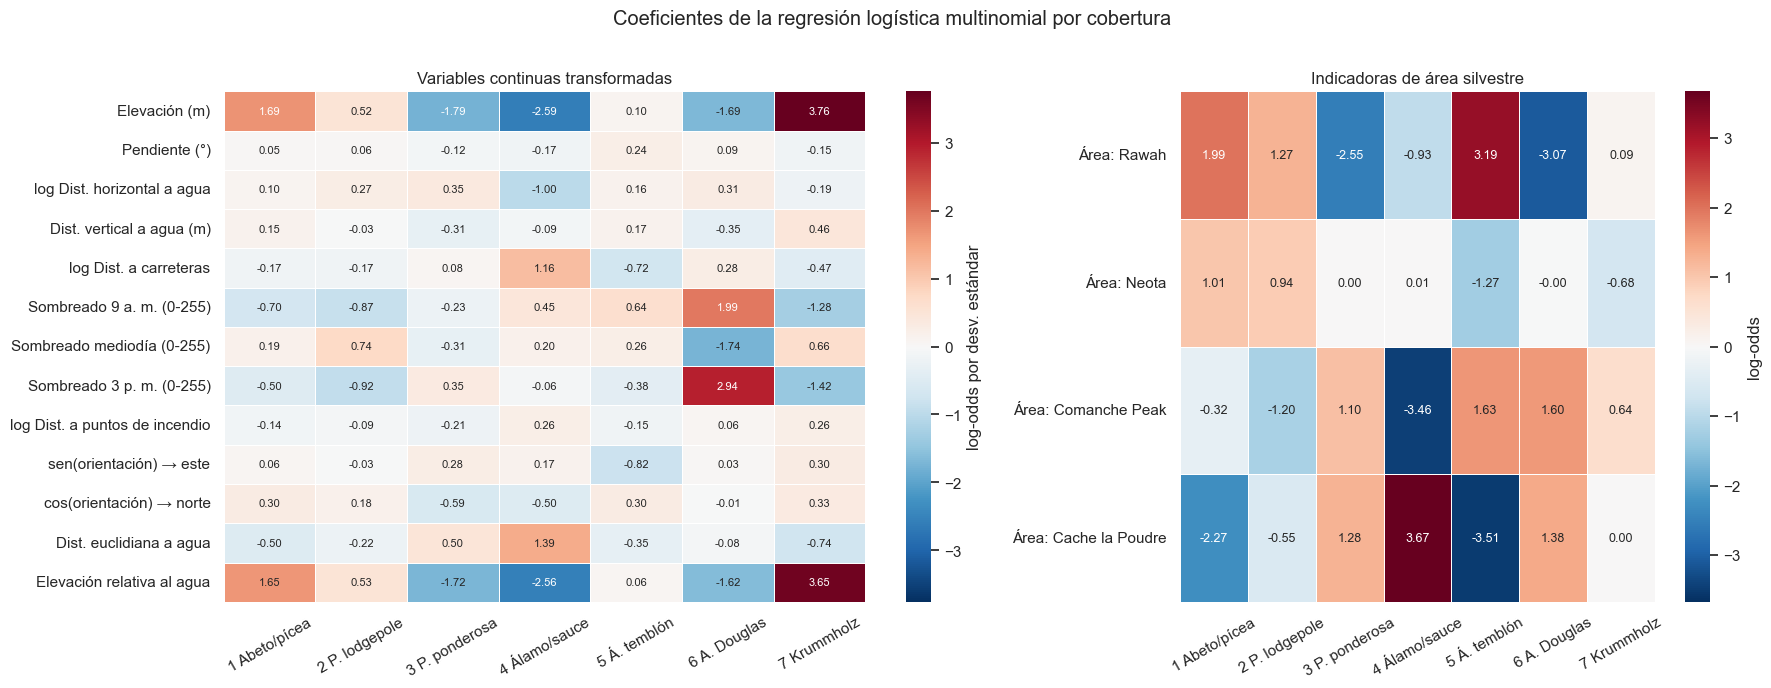

In [24]:
clf = modelo.named_steps["clf"]
escalador = modelo.named_steps["prep"].named_steps["scale"].named_transformers_["num"]
nombres = [n.split("__", 1)[1] for n in modelo.named_steps["prep"][-1].get_feature_names_out()]
coef = pd.DataFrame(clf.coef_.T, index=nombres, columns=[CLASS_SHORT[k] for k in clf.classes_])

NOMBRES_LEGIBLES = {
    **DISPLAY_NAMES,
    "Horizontal_Distance_To_Hydrology": "log Dist. horizontal a agua",
    "Horizontal_Distance_To_Roadways": "log Dist. a carreteras",
    "Horizontal_Distance_To_Fire_Points": "log Dist. a puntos de incendio",
    "Aspect_sin": "sen(orientación) → este",
    "Aspect_cos": "cos(orientación) → norte",
    "Dist_Hydrology_Euclid": "Dist. euclidiana a agua",
    "Elevation_Minus_VDH": "Elevación relativa al agua",
    **{c: f"Área: {WILD_NAMES[i + 1]}" for i, c in enumerate(WILD_COLS)},
    **{c: f"Suelo {c.rsplit('_', 1)[1]}" for c in SOIL_COLS},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6.8), gridspec_kw={"width_ratios": [1.35, 1]})
num = coef.loc[ENG_NUM_COLS].rename(index=NOMBRES_LEGIBLES)
lim = np.abs(num.to_numpy()).max()
sns.heatmap(num, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=axes[0],
            linewidths=0.5, linecolor="white", annot_kws={"size": 8}, cbar_kws={"label": "log-odds por desv. estándar"})
axes[0].set_title("Variables continuas transformadas")
areas = coef.loc[WILD_COLS].rename(index=NOMBRES_LEGIBLES)
lim2 = np.abs(areas.to_numpy()).max()
sns.heatmap(areas, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-lim2, vmax=lim2, ax=axes[1],
            linewidths=0.5, linecolor="white", annot_kws={"size": 9}, cbar_kws={"label": "log-odds"})
axes[1].set_title("Indicadoras de área silvestre")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Coeficientes de la regresión logística multinomial por cobertura", y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Efecto conjunto de +100 m de elevación con la distancia vertical al agua constante:
# aumentan a la vez Elevation y Elevation_Minus_VDH, por lo que se suman ambos efectos.
idx = {c: i for i, c in enumerate(ENG_NUM_COLS)}
s_e = escalador.scale_[idx["Elevation"]]
s_r = escalador.scale_[idx["Elevation_Minus_VDH"]]
efecto_100 = 100 * (coef.loc["Elevation"] / s_e + coef.loc["Elevation_Minus_VDH"] / s_r)
altitud = pd.DataFrame({
    "β Elevación": coef.loc["Elevation"],
    "β Elevación relativa al agua": coef.loc["Elevation_Minus_VDH"],
    "Efecto conjunto de +100 m (log-odds)": efecto_100,
    "Razón de odds por +100 m": np.exp(efecto_100),
})
altitud.round(3)

,β Elevación,β Elevación relativa al agua,Efecto conjunto de +100 m (log-odds),Razón de odds por +100 m
1 Abeto/pícea,1.688,1.652,1.191,3.292
2 P. lodgepole,0.522,0.527,0.374,1.454
3 P. ponderosa,-1.787,-1.720,-1.251,0.286
4 Álamo/sauce,-2.588,-2.563,-1.837,0.159
5 Á. temblón,0.100,0.064,0.058,1.060
6 A. Douglas,-1.693,-1.615,-1.180,0.307
7 Krummholz,3.759,3.655,2.644,14.075


In [26]:
filas = []
for clase in coef.columns:
    s = coef[clase].sort_values()
    positivos = ", ".join(f"{NOMBRES_LEGIBLES[v]} ({s[v]:+.2f})" for v in s.index[::-1][:4])
    negativos = ", ".join(f"{NOMBRES_LEGIBLES[v]} ({s[v]:+.2f})" for v in s.index[:3])
    filas.append({"Cobertura": clase, "Coeficientes positivos más influyentes": positivos,
                  "Coeficientes negativos más influyentes": negativos})
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(filas).set_index("Cobertura"))

,Coeficientes positivos más influyentes,Coeficientes negativos más influyentes
Cobertura,,
1 Abeto/pícea,"Suelo 9 (+2.14), Área: Rawah (+1.99), Suelo 21 (+1.96), Suelo 22 (+1.93)","Suelo 2 (-3.02), Suelo 37 (-2.55), Área: Cache la Poudre (-2.27)"
2 P. lodgepole,"Suelo 12 (+1.77), Suelo 28 (+1.61), Suelo 7 (+1.37), Suelo 25 (+1.33)","Suelo 1 (-2.67), Suelo 5 (-2.58), Suelo 4 (-1.84)"
3 P. ponderosa,"Suelo 2 (+2.33), Suelo 3 (+2.21), Suelo 1 (+1.83), Suelo 4 (+1.77)","Suelo 33 (-2.59), Área: Rawah (-2.55), Suelo 31 (-2.17)"
4 Álamo/sauce,"Área: Cache la Poudre (+3.67), Suelo 3 (+1.90), Dist. euclidiana a agua (+1.39), log Dist. a carreteras (+1.16)","Área: Comanche Peak (-3.46), Elevación (m) (-2.59), Elevación relativa al agua (-2.56)"
5 Á. temblón,"Área: Rawah (+3.19), Suelo 26 (+2.35), Suelo 19 (+1.83), Área: Comanche Peak (+1.63)","Área: Cache la Poudre (-3.51), Suelo 3 (-2.80), Suelo 12 (-2.67)"
6 A. Douglas,"Sombreado 3 p. m. (0-255) (+2.94), Sombreado 9 a. m. (0-255) (+1.99), Área: Comanche Peak (+1.60), Suelo 34 (+1.44)","Área: Rawah (-3.07), Suelo 28 (-1.93), Sombreado mediodía (0-255) (-1.74)"
7 Krummholz,"Suelo 4 (+3.78), Elevación (m) (+3.76), Elevación relativa al agua (+3.65), Suelo 37 (+3.41)","Suelo 13 (-2.59), Suelo 32 (-2.12), Suelo 25 (-1.53)"


**Gradiente altitudinal (H1).** La elevación aparece dos veces en el modelo, como elevación absoluta y como elevación relativa al curso de agua, y ambas variables están correlacionadas casi por completo, por lo que el modelo reparte entre ellas el mismo efecto con coeficientes casi idénticos. Su lectura correcta es conjunta: con la distancia vertical al agua constante, **cada 100 m de ascenso multiplican las *odds* del *krummholz* por 14,1 y las del bosque de pícea y abeto por 3,3**, mientras que reducen las del álamo y el sauce a cerca de una sexta parte (razón de *odds* de 0,16) y las del pino ponderosa y el abeto Douglas a menos de un tercio (0,29 y 0,31). Las clases del piso montano superior tienen efectos intermedios: moderadamente positivo para el pino contorta (1,45) y prácticamente neutro para el álamo temblón (1,06). El signo y el orden de los efectos reproducen exactamente la secuencia de pisos de la sección 1.4, lo que confirma la hipótesis H1.

**Iluminación y orientación.** El abeto Douglas tiene los coeficientes más grandes del bloque de sombreado, con signos opuestos (+1,99 a las 9:00, −1,74 al mediodía y +2,94 a las 15:00). Aisladamente, estos valores carecen de sentido físico; son el resultado de la colinealidad del bloque (VIF de 38 a 144). Solo su efecto combinado tiene lectura física: el coeficiente negativo del mediodía favorece a las celdas con menor iluminación cenital, es decir, a laderas de mayor pendiente y menos expuestas, coherente con el nicho de la especie. El coseno de la orientación (componente norte) es positivo para las coberturas subalpinas y negativo para el pino ponderosa (−0,59) y el álamo y el sauce (−0,50), en línea con la preferencia del pino ponderosa por laderas cálidas.

**Hidrología.** El álamo y el sauce tienen el patrón hidrológico más marcado: coeficiente negativo en el logaritmo de la distancia horizontal al agua (−1,00), que favorece a las celdas junto al cauce, y positivo en la distancia euclidiana (+1,39). El signo de esta última, contraintuitivo por sí solo, refleja la correlación entre las variables hidrológicas: la distancia euclidiana corrige la representación logarítmica para las celdas alejadas, y el efecto neto sigue concentrando la probabilidad cerca del agua, como muestra el perfil de la sección 5.3.

**Áreas silvestres y suelos.** El área de Cache la Poudre aporta el mayor coeficiente positivo al álamo y el sauce (+3,67) y el mayor negativo al álamo temblón (−3,51), coherente con la presencia exclusiva del primero y la ausencia del segundo en esa área; Rawah, en cambio, favorece al álamo temblón (+3,19). Los suelos tienen coeficientes grandes en las clases cuyos nichos son edáficamente específicos: los suelos 1 a 4 (complejos de afloramiento rocoso de las familias Cathedral, Vanet, Ratake y Haploborolis, propios de las laderas del cañón) favorecen al pino ponderosa, y los suelos 4, 37 y 39 favorecen al *krummholz* (los dos últimos son complejos de criortentes y afloramientos rocosos extremadamente pedregosos, propios del límite arbóreo). Estos coeficientes deben interpretarse como indicadores geográficos más que como efectos causales del suelo: varias unidades edáficas están confinadas a un área o a una franja altitudinal y sus coeficientes absorben información de localización.

## 6. Síntesis y alcance

**Hallazgos principales.**

1. **El gradiente altitudinal estructura el problema.** La elevación explica el 62 % de su varianza a través de la cobertura y es la variable con mayor peso en el modelo; sus efectos reproducen la zonificación de los pisos montano inferior, montano superior, subalpino y del límite arbóreo de la Cordillera Frontal.
2. **La regresión logística multinomial supera ampliamente a la inferencia ingenua.** En el conjunto de prueba alcanza 0,724 de *accuracy* y 0,557 de F1 macro, frente a 0,488 y 0,094 del clasificador mayoritario, con intervalos de confianza estrechos.
3. **El modelo no sobreajusta: está limitado por sesgo.** La brecha entre entrenamiento y prueba es inferior a dos milésimas y la curva de aprendizaje se estabiliza con unas 30.000 celdas.
4. **Los errores tienen estructura ecológica.** La confusión entre pares de coberturas sigue su solapamiento altitudinal (r = 0,82) y se concentra en cuatro transiciones: la sucesión entre el pino contorta y la pícea y el abeto, el ecotono del límite arbóreo, la partición por orientación entre el pino ponderosa y el abeto Douglas, y el nicho ribereño no monótono del álamo y el sauce. El álamo temblón, cuya distribución responde a la historia de perturbaciones, es prácticamente irreconocible para el modelo.

**Limitaciones.**

- **Forma funcional.** Las fronteras de decisión lineales no representan interacciones (pendiente × orientación, elevación × área) ni respuestas no monótonas, que son precisamente las que separan las coberturas dentro de cada piso.
- **Variables ausentes.** La historia de incendios, la edad de los rodales, el nivel freático y la exposición al viento determinan parte de la cobertura y no están en el conjunto de datos; el error asociado a ellas es irreducible con predictoras cartográficas.
- **Dependencia espacial.** Sin coordenadas, la partición aleatoria no controla la autocorrelación espacial, y las métricas son válidas dentro de las cuatro áreas muestreadas.
- **Vigencia temporal.** La cartografía es anterior a 1998 y no refleja perturbaciones posteriores de gran magnitud en la región, como los incendios de 2020 que afectaron a extensas superficies del distrito de Canyon Lakes.

**Alcance para la modelización.** El diagnóstico orienta la etapa siguiente del proyecto hacia modelos capaces de representar interacciones y respuestas no lineales (árboles de decisión, métodos de *ensemble* y redes neuronales), cuyo margen de mejora estimado sobre la regresión logística supera los 15 puntos de F1 macro. Al mismo tiempo, las transiciones sucesionales delimitan un techo de desempeño que ningún modelo basado solo en topografía podrá superar, y las clases cuya distribución depende de la perturbación seguirán siendo las más difíciles.

## 7. Artefactos de datos para la capa de visualización interactiva

Los resultados del modelo base se exportan como tablas compactas en formato largo (*tidy*) al directorio `data_dashboard/` de la raíz del proyecto, de modo que la aplicación interactiva consuma resultados ya calculados sin reentrenar el modelo:

| Archivo | Contenido | Columnas |
|---|---|---|
| `metricas_comparativas.csv` | Métricas de prueba de las líneas base triviales y de la regresión logística, con intervalos de confianza *bootstrap* para el modelo y métricas de entrenamiento para el diagnóstico de ajuste | `modelo`, `tipo`, `conjunto`, `metrica`, `valor`, `ic_inferior`, `ic_superior` |
| `matriz_confusion.csv` | Una fila por combinación de cobertura real y predicha (49 filas), con el conteo y sus normalizaciones por fila y por columna | `id_real`, `clase_real`, `id_predicha`, `clase_predicha`, `conteo`, `prop_real`, `prop_predicha` |
| `importancia_coeficientes.csv` | Una fila por variable transformada y cobertura (57 × 7 = 399 filas), con el coeficiente, su magnitud, la razón de *odds* y el rango de importancia dentro de la clase | `variable`, `variable_legible`, `grupo`, `id_clase`, `clase`, `coeficiente`, `abs_coeficiente`, `odds_ratio`, `rango_en_clase` |

In [27]:
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

# 1. Métricas comparativas
filas = []
for nombre in tabla_test.index:
    for m in METRICAS:
        es_modelo = nombre == "Regresión logística"
        filas.append({
            "modelo": nombre, "tipo": "Modelo base" if es_modelo else "Línea base trivial", "conjunto": "prueba",
            "metrica": m, "valor": tabla_test.loc[nombre, m],
            "ic_inferior": ic.loc[m, "IC 95 % inferior"] if es_modelo else np.nan,
            "ic_superior": ic.loc[m, "IC 95 % superior"] if es_modelo else np.nan,
        })
for m in METRICAS:
    filas.append({"modelo": "Regresión logística", "tipo": "Modelo base", "conjunto": "entrenamiento",
                  "metrica": m, "valor": res_train[m], "ic_inferior": np.nan, "ic_superior": np.nan})
metricas_csv = pd.DataFrame(filas)

# 2. Matriz de confusión en formato largo
cm_col = cm / cm.sum(axis=0, keepdims=True)
matriz_csv = pd.DataFrame([
    {"id_real": r, "clase_real": CLASS_NAMES[r], "id_predicha": p, "clase_predicha": CLASS_NAMES[p],
     "conteo": int(cm[r - 1, p - 1]), "prop_real": cm_norm[r - 1, p - 1], "prop_predicha": cm_col[r - 1, p - 1]}
    for r in CLASES for p in CLASES
])

# 3. Coeficientes por clase
grupo = {**{c: "Continua" for c in ENG_NUM_COLS}, **{c: "Área silvestre" for c in WILD_COLS},
         **{c: "Tipo de suelo" for c in SOIL_COLS}}
coef_largo = pd.DataFrame(clf.coef_.T, index=nombres, columns=clf.classes_).stack().reset_index()
coef_largo.columns = ["variable", "id_clase", "coeficiente"]
coef_largo.insert(1, "variable_legible", coef_largo["variable"].map(NOMBRES_LEGIBLES))
coef_largo.insert(2, "grupo", coef_largo["variable"].map(grupo))
coef_largo.insert(4, "clase", coef_largo["id_clase"].map(CLASS_NAMES))
coef_largo["abs_coeficiente"] = coef_largo["coeficiente"].abs()
coef_largo["odds_ratio"] = np.exp(coef_largo["coeficiente"])
coef_largo["rango_en_clase"] = coef_largo.groupby("id_clase")["abs_coeficiente"].rank(ascending=False, method="first").astype(int)
coef_csv = coef_largo.sort_values(["id_clase", "rango_en_clase"]).reset_index(drop=True)

archivos = {
    "metricas_comparativas.csv": metricas_csv,
    "matriz_confusion.csv": matriz_csv,
    "importancia_coeficientes.csv": coef_csv,
}
for nombre, tabla in archivos.items():
    tabla.round(6).to_csv(DASHBOARD_DIR / nombre, index=False, encoding="utf-8")

pd.DataFrame({
    "Filas": [len(t) for t in archivos.values()],
    "Columnas": [t.shape[1] for t in archivos.values()],
    "Tamaño (KB)": [round((DASHBOARD_DIR / n).stat().st_size / 1024, 1) for n in archivos],
}, index=[f"data_dashboard/{n}" for n in archivos])

,Filas,Columnas,Tamaño (KB)
data_dashboard/metricas_comparativas.csv,30,7,2.3
data_dashboard/matriz_confusion.csv,49,7,3.1
data_dashboard/importancia_coeficientes.csv,399,9,36.6


In [28]:
coef_csv[coef_csv["rango_en_clase"] <= 2].head(14)

,variable,variable_legible,grupo,id_clase,clase,coeficiente,abs_coeficiente,odds_ratio,rango_en_clase
0,Soil_Type_2,Suelo 2,Tipo de suelo,1,Abeto/pícea (Spruce/Fir),-3.023047,3.023047,0.048653,1
1,Soil_Type_37,Suelo 37,Tipo de suelo,1,Abeto/pícea (Spruce/Fir),-2.553834,2.553834,0.077783,2
57,Soil_Type_1,Suelo 1,Tipo de suelo,2,Pino lodgepole,-2.669496,2.669496,0.069287,1
58,Soil_Type_5,Suelo 5,Tipo de suelo,2,Pino lodgepole,-2.579044,2.579044,0.075846,2
114,Soil_Type_33,Suelo 33,Tipo de suelo,3,Pino ponderosa,-2.589996,2.589996,0.075020,1
115,Wilderness_Area_1,Área: Rawah,Área silvestre,3,Pino ponderosa,-2.549366,2.549366,0.078131,2
171,Wilderness_Area_4,Área: Cache la Poudre,Área silvestre,4,Álamo/sauce (Cottonwood/Willow),3.670627,3.670627,39.276506,1
172,Wilderness_Area_3,Área: Comanche Peak,Área silvestre,4,Álamo/sauce (Cottonwood/Willow),-3.459350,3.459350,0.031450,2
228,Wilderness_Area_4,Área: Cache la Poudre,Área silvestre,5,Álamo temblón (Aspen),-3.513861,3.513861,0.029782,1
229,Wilderness_Area_1,Área: Rawah,Área silvestre,5,Álamo temblón (Aspen),3.194710,3.194710,24.403092,2


## Apéndice: reproducibilidad

- **Entorno:** Python 3.9 en el ambiente de conda `ml_venv`, con las dependencias fijadas en `requirements.txt` (scikit-learn 1.3.0, pandas 2.1.0, numpy 1.25.2, matplotlib 3.7.2, seaborn 0.12.2 y jupyter-book 0.15.1).
- **Datos:** `covertype.csv` en la raíz del proyecto (581.012 filas y 55 columnas), equivalente al archivo `covtype.data` del repositorio UCI con los nombres de las columnas agregados.
- **Semilla:** `RANDOM_STATE = 42` en la partición, las submuestras estratificadas, los pliegues de validación cruzada, el *bootstrap*, los clasificadores triviales y el modelo.
- **Hiperparámetros:** reutilizados de la fase exploratoria (ingeniería de variables, $C = 1{,}0$, sin ponderación de clases); la búsqueda en rejilla no se repite.
- **Estructura de archivos:**

```text
MachineLearning/
├── covertype.csv
├── data_dashboard/                    Tablas exportadas por la sección 7
│   ├── metricas_comparativas.csv
│   ├── matriz_confusion.csv
│   └── importancia_coeficientes.csv
└── jbook_ml_entregable2/
    ├── _config.yml                    Configuración del libro
    ├── _toc.yml                       Tabla de contenido
    ├── _utils.py                      Carga, partición, pipelines y constantes
    ├── Entregable2_Covertype.ipynb    Informe
    ├── bibliografia.md
    ├── references.bib
    ├── logo.png
    ├── _build/html/                   Sitio compilado
    └── docs/                          Copia del sitio para GitHub Pages
```

El módulo auxiliar compartido es el siguiente:

```{literalinclude} _utils.py
:language: python
```